# EDA


### We will answer questions like
#### What kind of borrowers default?
#### What kind of loans become risky?
#### How does risk evolve before and during the crisis

Originating file EDA


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
#importing both the files
og_df = pd.read_parquet(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\master_origination_clean.parquet")
m_df = pd.read_parquet(
    r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\master_monthly_performance_clean.parquet"
    
)

In [3]:
og_df.head()

,cred_score,first_payment_date,first_time_homebuyer_flag,maturity_date,metro_code_msa,mortgage_insurance_percent,unit_no,occupancy_status,og_cltv,og_dti,...,seller_name,servicer_name,super_conforming_flag,pre_relief_refinance_loan_seq_no,special_elig_program,relief_refinance_indicator,prop_val_method,int_only_indicator,MI_cal_indicator,origination_year
0,790,200211,N,203003,Unknown,30,1,P,92,29,...,Other sellers,Other servicers,N,Unknown,9,not applicable,7,N,9,2000
1,771,200011,N,201510,Unknown,0,1,P,61,30,...,Other sellers,Other servicers,N,Unknown,9,not applicable,7,N,9,2000
2,762,200110,N,203003,39300.0,0,3,P,76,23,...,Other sellers,Other servicers,N,Unknown,9,not applicable,7,N,9,2000
3,737,200104,N,203004,16974.0,25,1,P,87,35,...,"NORWEST MORTGAGE, INC.","WELLS FARGO HOME MORTGAGE, INC.",N,Unknown,9,not applicable,7,N,9,2000
4,594,200003,N,203002,23460.0,0,1,P,80,24,...,Other sellers,CHASE MANHATTAN MORTGAGE CORPORATION,N,Unknown,9,not applicable,7,N,9,2000


In [4]:
og_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 33 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   cred_score                        550000 non-null  int64  
 1   first_payment_date                550000 non-null  int64  
 2   first_time_homebuyer_flag         550000 non-null  str    
 3   maturity_date                     550000 non-null  int64  
 4   metro_code_msa                    550000 non-null  string 
 5   mortgage_insurance_percent        550000 non-null  int64  
 6   unit_no                           550000 non-null  int64  
 7   occupancy_status                  550000 non-null  str    
 8   og_cltv                           550000 non-null  int64  
 9   og_dti                            550000 non-null  int64  
 10  og_upb                            550000 non-null  int64  
 11  og_ltv                            550000 non-null  int64  
 12 

In [5]:
og_df.describe()

,cred_score,first_payment_date,maturity_date,mortgage_insurance_percent,unit_no,og_cltv,og_dti,og_upb,og_ltv,og_int_rate,og_loan_term,no_of_borrowers,special_elig_program,prop_val_method,MI_cal_indicator,origination_year
count,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,5.500000e+05,550000.000000,550000.000000,550000.000000,550000.000000,550000.0,550000.0,550000.0,550000.000000
mean,758.684778,200523.740013,203105.762504,3.413564,1.029140,70.744047,86.290762,1.685541e+05,69.255356,6.079204,310.808411,1.631440,9.0,7.0,9.0,2005.000000
std,501.265832,317.845304,763.710391,9.922197,0.450148,19.778978,219.535976,9.433755e+04,19.031675,1.013823,79.117047,1.761196,0.0,0.0,0.0,3.162281
min,300.000000,200002.000000,200308.000000,0.000000,1.000000,6.000000,1.000000,9.000000e+03,6.000000,2.625000,30.000000,1.000000,9.0,7.0,9.0,2000.000000
25%,695.000000,200212.000000,202508.000000,0.000000,1.000000,60.000000,25.000000,1.000000e+05,59.000000,5.375000,240.000000,1.000000,9.0,7.0,9.0,2002.000000
50%,742.000000,200509.000000,203311.000000,0.000000,1.000000,75.000000,34.000000,1.480000e+05,75.000000,6.000000,360.000000,2.000000,9.0,7.0,9.0,2005.000000
75%,777.000000,200806.000000,203707.000000,0.000000,1.000000,80.000000,44.000000,2.200000e+05,80.000000,6.625000,360.000000,2.000000,9.0,7.0,9.0,2008.000000
max,9999.000000,201702.000000,205301.000000,999.000000,99.000000,999.000000,999.000000,1.095000e+06,999.000000,11.950000,513.000000,99.000000,9.0,7.0,9.0,2010.000000


In [6]:
m_df.describe()

,monthly_reporting_period,current_actual_upb,loan_age,remaining_months_to_legal_maturity,defect_settlement_date,zero_balance_code,zero_balance_effective_date,current_interest_rate,current_non_interest_bearing_upb,ddlpi,...,taxes_and_insurance,miscellaneous_expenses,actual_loss_calculation,cumulative_modification_cost,eltv,zero_balance_removal_upb,delinquent_accrued_interest,current_month_modification_cost,interest_bearing_upb,origination_year
count,3.305839e+07,3.305839e+07,3.305839e+07,3.305809e+07,3565.000000,536749.000000,536749.000000,3.305839e+07,3.305839e+07,59938.000000,...,17278.000000,17278.000000,17351.000000,11405.000000,3.195561e+06,5.367490e+05,17351.000000,972706.000000,3.305839e+07,3.305839e+07
mean,2.009926e+05,1.356912e+05,5.112343e+01,2.577542e+02,200965.144180,1.718319,200975.737473,5.814148e+00,2.688806e+02,201531.922987,...,-6897.537223,-964.872142,-75267.716778,27941.861211,1.884787e+02,1.459616e+05,17552.062412,331.339681,1.354223e+05,2.005349e+03
std,4.948158e+02,8.995157e+04,4.653098e+01,9.673490e+01,384.710601,6.260710,526.709416,9.670454e-01,4.521465e+03,654.798984,...,11207.588247,3046.387586,62847.457288,31685.638531,3.529308e+02,9.615357e+04,19804.499199,355.171935,8.967334e+04,2.908346e+00
min,2.000010e+05,0.000000e+00,0.000000e+00,-7.000000e+01,200006.000000,1.000000,200002.000000,2.000000e+00,0.000000e+00,200002.000000,...,-206299.400000,-131814.680000,-597948.660000,-18824.830000,1.000000e+00,0.000000e+00,-947.030000,-1113.420000,0.000000e+00,2.000000e+03
25%,2.007010e+05,7.006531e+04,1.600000e+01,1.710000e+02,200805.000000,1.000000,200509.000000,5.250000e+00,0.000000e+00,201002.000000,...,-8182.275000,-1043.150000,-106661.540000,3338.280000,2.100000e+01,7.747841e+04,6389.495000,39.290000,7.000000e+04,2.003000e+03
50%,2.010010e+05,1.160000e+05,3.700000e+01,2.950000e+02,201012.000000,1.000000,201008.000000,5.875000e+00,0.000000e+00,201904.000000,...,-3803.075000,-400.000000,-62653.580000,18021.640000,3.800000e+01,1.284059e+05,11629.430000,237.630000,1.158408e+05,2.005000e+03
75%,2.013010e+05,1.823514e+05,7.300000e+01,3.380000e+02,201302.000000,1.000000,201303.000000,6.375000e+00,0.000000e+00,202103.000000,...,-1540.042500,-255.000000,-30428.350000,42163.420000,6.300000e+01,1.988219e+05,21123.000000,493.970000,1.820000e+05,2.008000e+03
max,2.025090e+05,1.094000e+06,3.070000e+02,5.920000e+02,202409.000000,96.000000,202509.000000,5.000000e+01,3.150000e+05,204009.000000,...,188936.380000,33328.100000,245165.500000,357382.260000,9.990000e+02,1.042218e+06,368043.250000,24439.320000,1.094000e+06,2.010000e+03


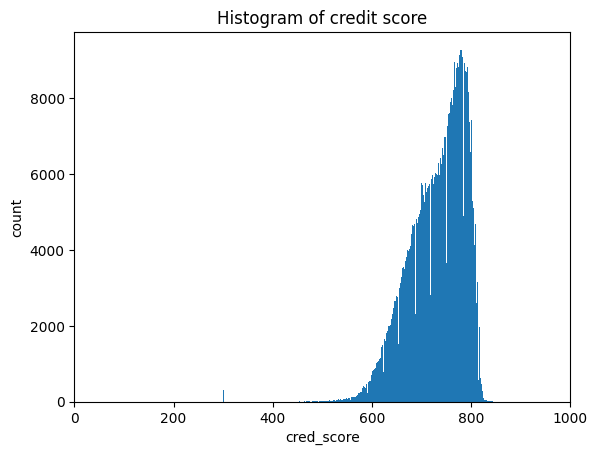

In [9]:
#plotting histograms
import matplotlib.pyplot as plt

plt.hist(og_df['cred_score'].dropna(), bins=5000)
plt.xlabel('cred_score')
plt.ylabel('count')
plt.xlim(0,1000)
plt.title('Histogram of credit score')
plt.show()

C:\Temp\ipykernel_18952\2807461362.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Temp\ipykernel_18952\2807461362.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Temp\ipykernel_18952\2807461362.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Temp\ipykernel_18952\2807461362.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Temp\ipykernel_18952\28074613

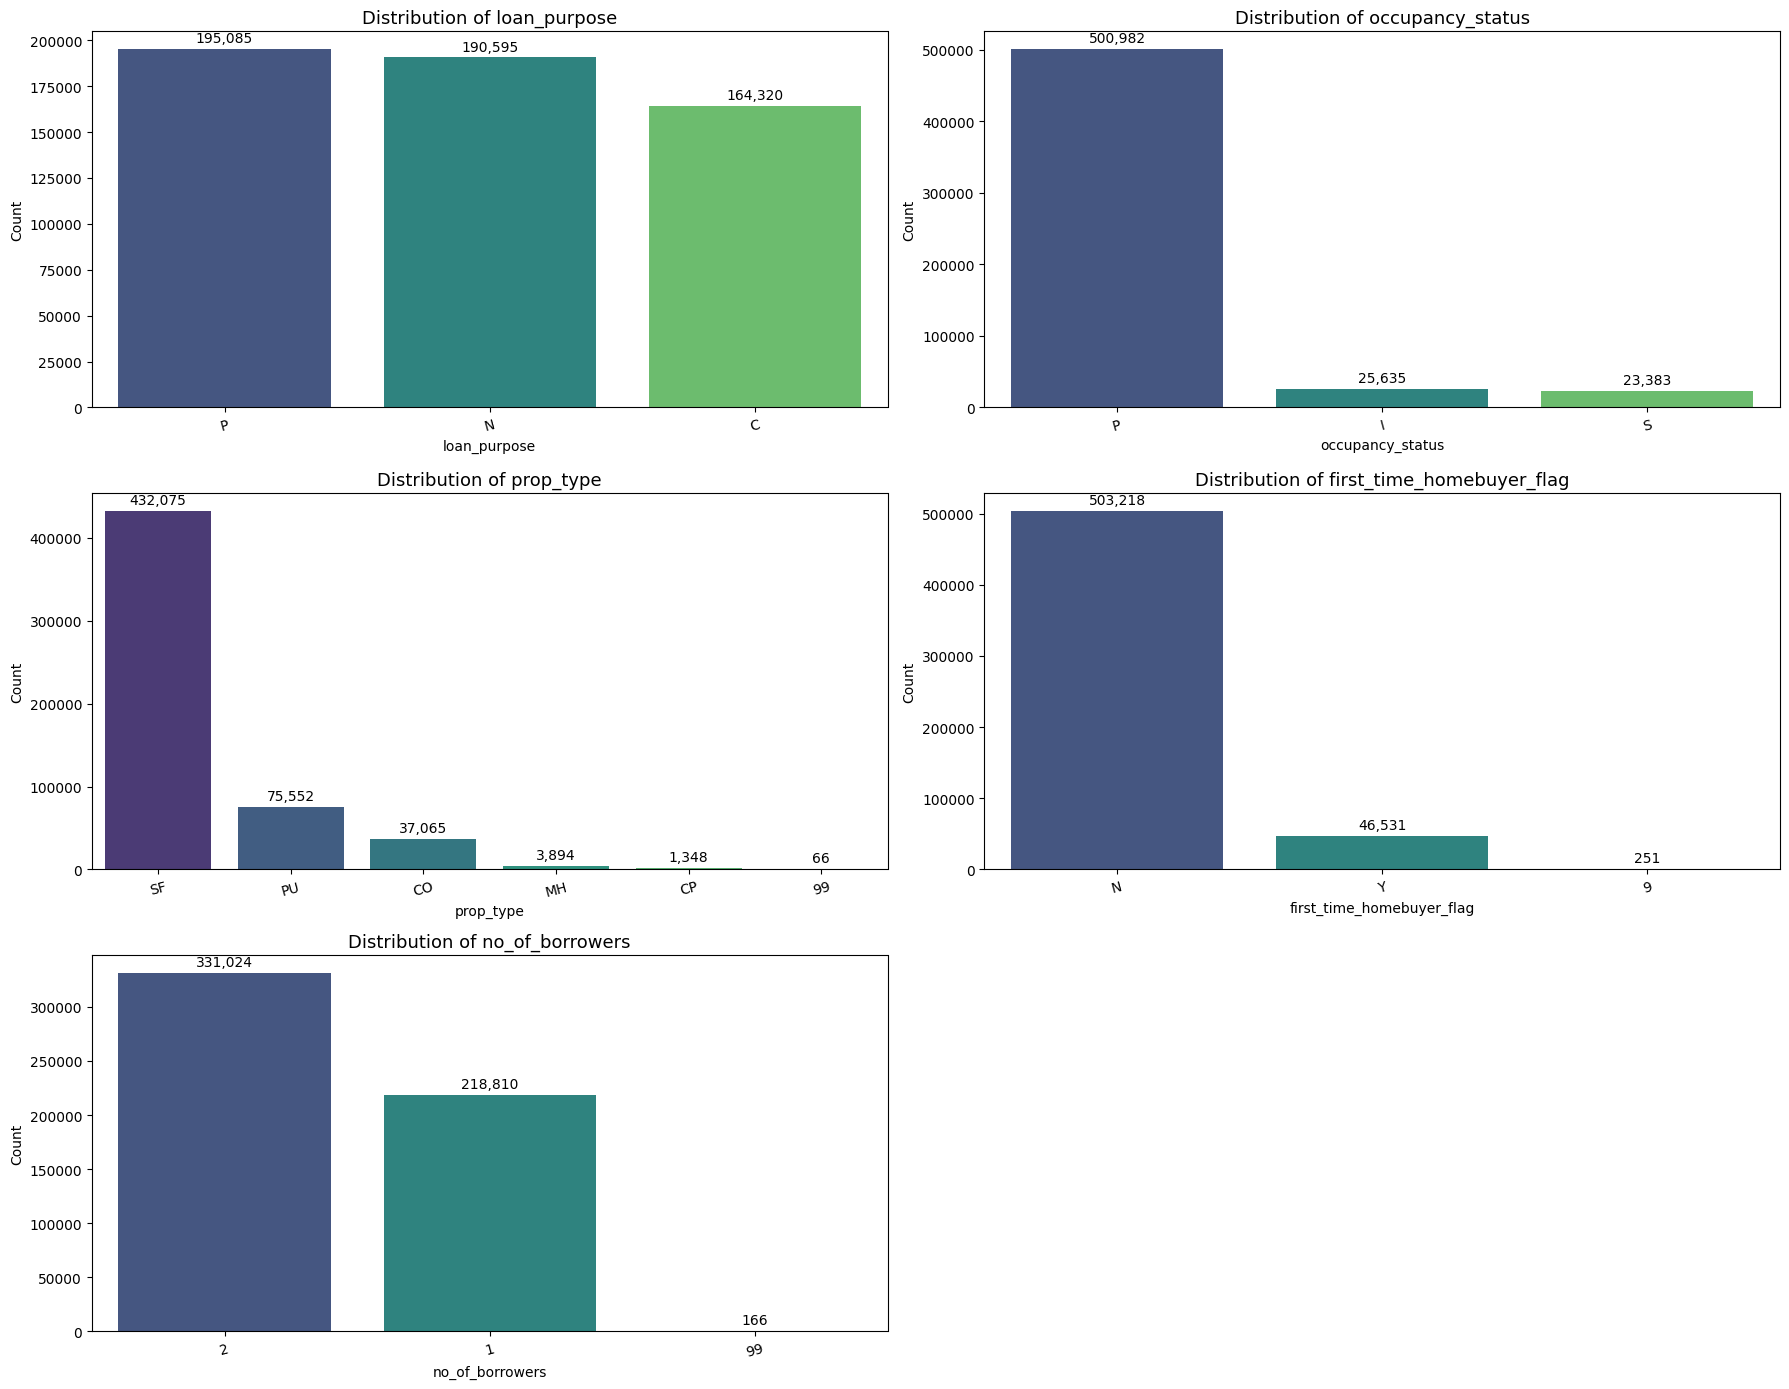

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the important categorical features
cat_vars = [
    "loan_purpose", 
    "occupancy_status", 
    "prop_type", 
    "first_time_homebuyer_flag", 
    "no_of_borrowers"
]

# 2. Setup a 3x2 Grid for Count Plots
plt.figure(figsize=(18, 14))

for i, var in enumerate(cat_vars, start=1):
    plt.subplot(3, 2, i)
    
    # Filter non-nulls and plot counts sorted by frequency
    clean_data = og_df[og_df[var].notna()]
    sns.countplot(
        data=clean_data, 
        x=var, 
        order=clean_data[var].value_counts().index, 
        palette="viridis"
    )
    
    # Add textual counts on top of each bar for complete transparency
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
        
    plt.title(f"Distribution of {var}", fontsize=13)
    plt.xticks(rotation=15)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

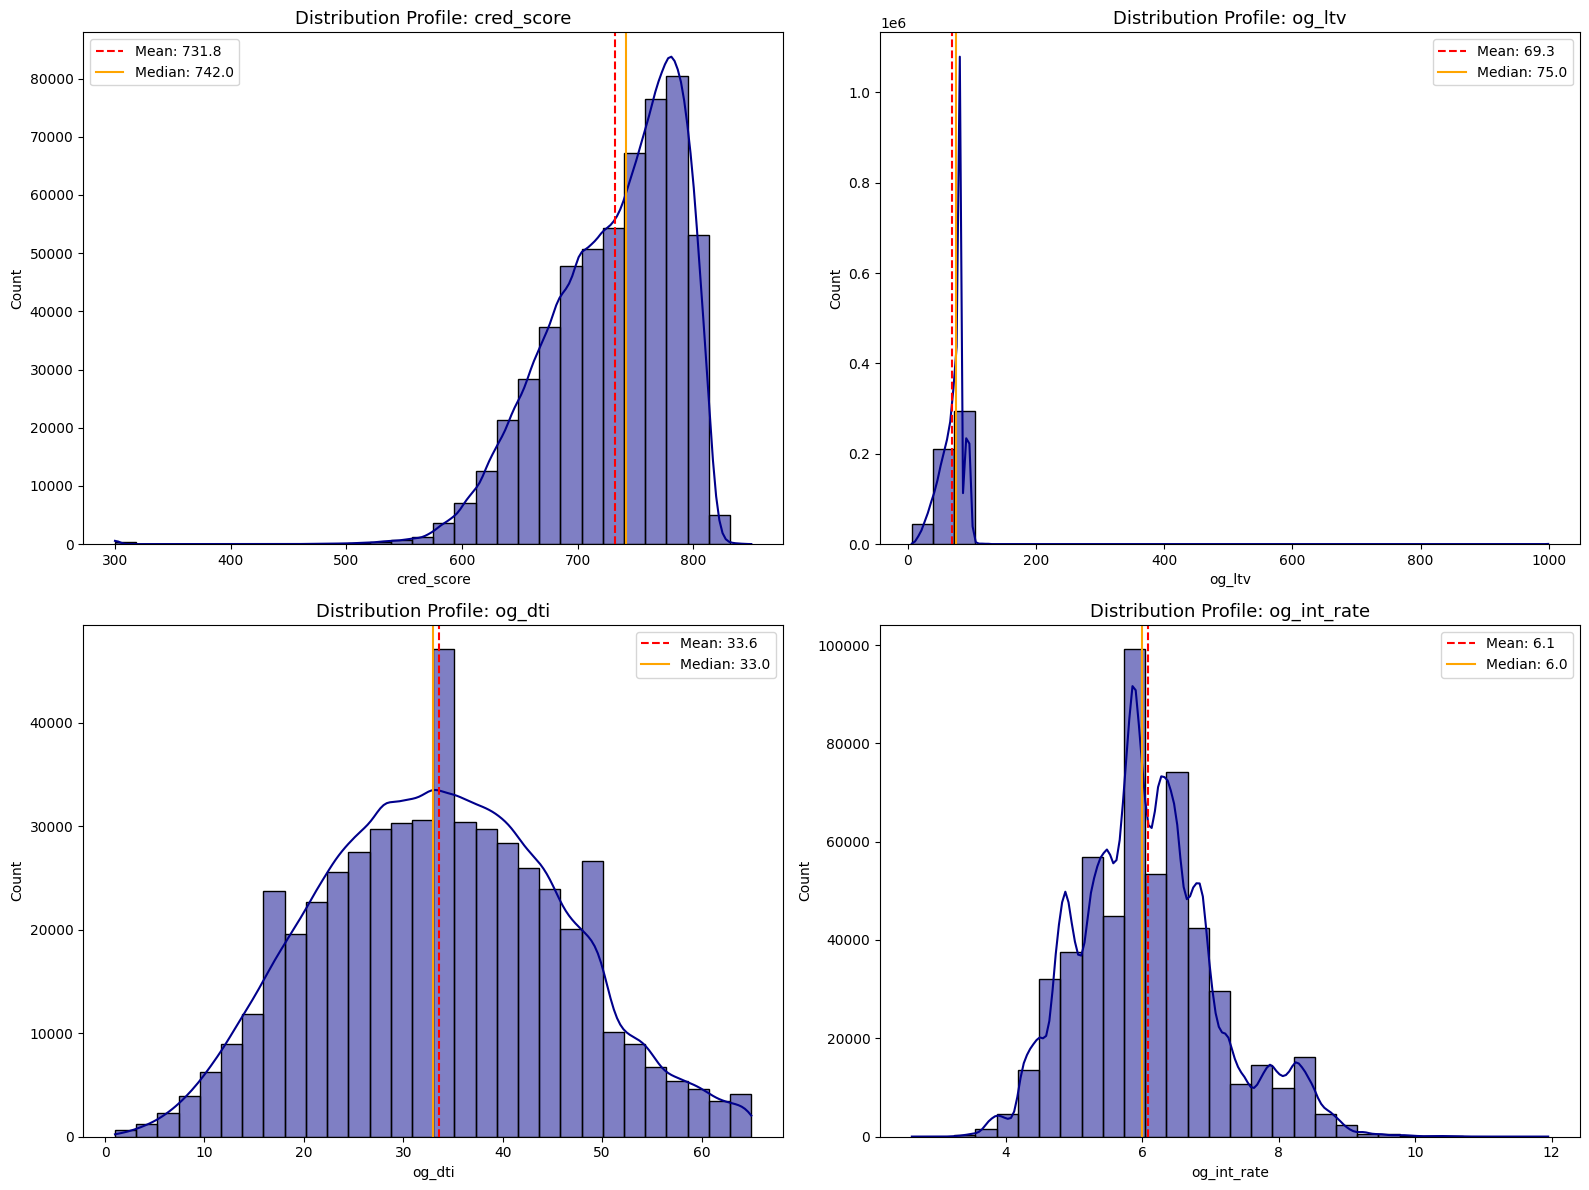

In [11]:
# 1. Define the continuous numeric features
num_vars = ["cred_score", "og_ltv", "og_dti", "og_int_rate"]

# 2. Setup a 2x2 Grid for continuous profiles
plt.figure(figsize=(16, 12))

for i, var in enumerate(num_vars, start=1):
    plt.subplot(2, 2, i)
    
    # Clean standard Freddie Mac data placeholder anomalies dynamically
    if var == "cred_score":
        plot_df = og_df[(og_df[var].notna()) & (og_df[var] <= 850)] # Cap at valid FICO Max
    elif var == "og_dti":
        plot_df = og_df[(og_df[var].notna()) & (og_df[var] < 999)]   # Strip out missing indicator
    else:
        plot_df = og_df[og_df[var].notna()]
        
    # Plot data with Kernel Density Estimate (KDE) curve line
    sns.histplot(data=plot_df, x=var, bins=30, kde=True, color="darkblue")
    
    # Print underlying distribution metrics as text labels directly inside the chart
    mean_val = plot_df[var].mean()
    median_val = plot_df[var].median()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    plt.axvline(median_val, color='orange', linestyle='-', label=f'Median: {median_val:.1f}')
    
    plt.title(f"Distribution Profile: {var}", fontsize=13)
    plt.legend()

plt.tight_layout()
plt.show()

C:\Temp\ipykernel_18952\738389752.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


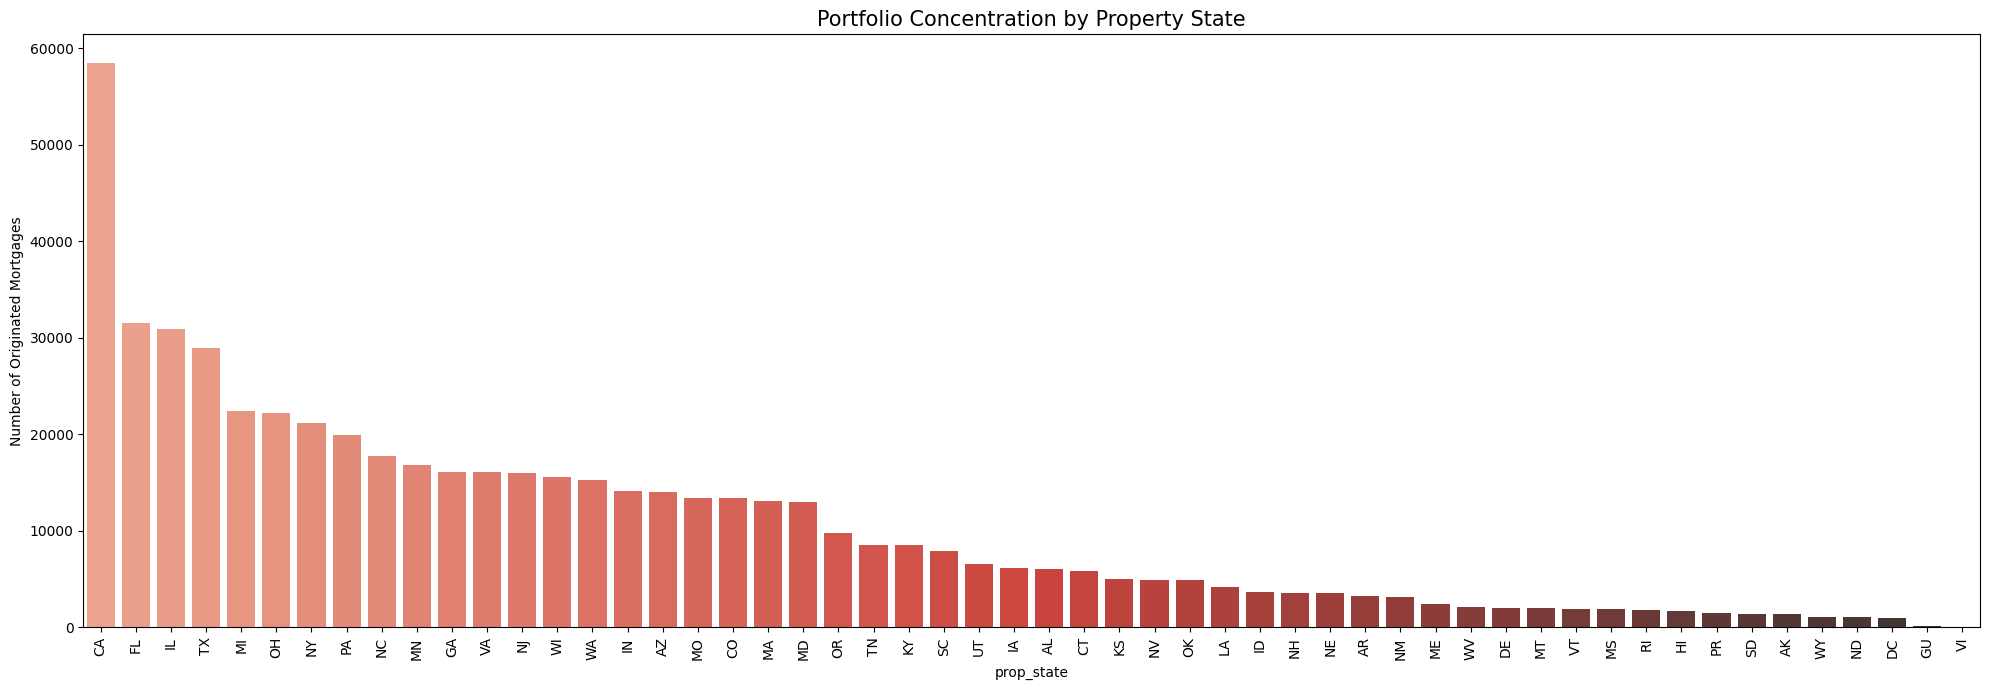

In [12]:
# Giant canvas for high-density categorical features
plt.figure(figsize=(20, 7))

state_data = og_df[og_df["prop_state"].notna()]
sns.countplot(
    data=state_data, 
    x="prop_state", 
    order=state_data["prop_state"].value_counts().index, 
    palette="Reds_d"
)

plt.title("Portfolio Concentration by Property State", fontsize=15)
plt.xticks(rotation=90, fontsize=10) # Flip letters 90 degrees to completely avoid overlaps
plt.ylabel("Number of Originated Mortgages")
plt.tight_layout()
plt.show()

we check default rate vs credit score

In [13]:
arr = m_df.loc[
    m_df["zero_balance_code"].notna(),
    "zero_balance_code"
].value_counts()
# adding query of notna else the value counts will also count the NaNs which is not what we want here
print(arr)

zero_balance_code
1.0     511190
9.0      10878
16.0      4646
3.0       4178
2.0       2712
96.0      2145
15.0      1000
Name: count, dtype: int64


 Also we have observed that there is a class imbalance in default rates so we need to deal with it

In [14]:
default_prop = (arr[9]+arr[3]+arr[2]+arr[15])/arr.sum()
print(default_prop)

0.034966064212509015


In [15]:
# now creating bins for credit score and looking at default rates
def credit_vs_default():
    default_codes = [2,3,9,15]
    

In [16]:
import numpy as np
import pandas as pd

def analyze_credit_score_vs_default(orig_df, perf_df):
    """
    Analyzes the relationship between baseline credit scores and loan default rates
    by creating risk bins and calculating the historical default rate.
    """
    # -------------------------------------------------------------------------
    # 1. Identify Defaulted Loans from the Performance File
    #    Freddie Mac Default codes: 02 (Third-Party Sale), 03 (Short Sale), 
    #    09 (REO Disposition), 15 (Whole Loan Sale)
    # -------------------------------------------------------------------------
    default_codes = [2, 3,9,15]
    
    # Track unique loan IDs that ever experienced a default code
    defaulted_loans = m_df[m_df["zero_balance_code"].isin(default_codes)]["loan_seq_no"].unique()
    
    # -------------------------------------------------------------------------
    # 2. Isolate Credit Scores from Origination File
    # -------------------------------------------------------------------------
    # Drop rows where credit score is missing or placeholder (Freddie Mac uses 9999)
    analysis_df = og_df[
        (og_df["cred_score"].notna()) & 
        (og_df["cred_score"] != 9999)
    ][["loan_seq_no", "cred_score"]].copy()
    
    # Create a target flag: 1 if the loan defaulted down the road, 0 otherwise
    analysis_df["is_default"] = analysis_df["loan_seq_no"].isin(defaulted_loans).astype(int)
    
    # -------------------------------------------------------------------------
    # 3. Create Industry-Standard Credit Score Bins
    # -------------------------------------------------------------------------
    bins = [0, 579, 669, 739, 799, 850]
    labels = ["Poor (300-579)", "Fair (580-669)", "Good (670-739)", "Very Good (740-799)", "Exceptional (800-850)"]
    
    analysis_df["credit_score_tier"] = pd.cut(
        analysis_df["cred_score"], 
        bins=bins, 
        labels=labels, 
        include_lowest=True
        )
    summary = analysis_df.groupby("credit_score_tier", observed=False).agg(
        total_loans=("is_default", "count"),
        total_defaults=("is_default", "sum")
    ).reset_index()
    
    # Calculate the Default Rate percentage
    summary["default_rate_pct"] = (summary["total_defaults"] / summary["total_loans"]) * 100
    
    # Calculate portfolio share for extra context
    summary["portfolio_share_pct"] = (summary["total_loans"] / summary["total_loans"].sum()) * 100
    
    return summary

# --- Execution ---
# Assumes you just loaded your dataframes from your processed parquet files
credit_risk_profile = analyze_credit_score_vs_default(og_df.rename(columns={'cred_score': 'credit_score'}), m_df)

# Print your baseline credit risk matrix
print(credit_risk_profile.to_string(index=False))

    credit_score_tier  total_loans  total_defaults  default_rate_pct  portfolio_share_pct
       Poor (300-579)         3611             287          7.947937             0.658454
       Fair (580-669)        77895            6249          8.022338            14.203893
       Good (670-739)       184573            8070          4.372254            33.656269
  Very Good (740-799)       242654            3761          1.549944            44.247145
Exceptional (800-850)        39673             372          0.937665             7.234239


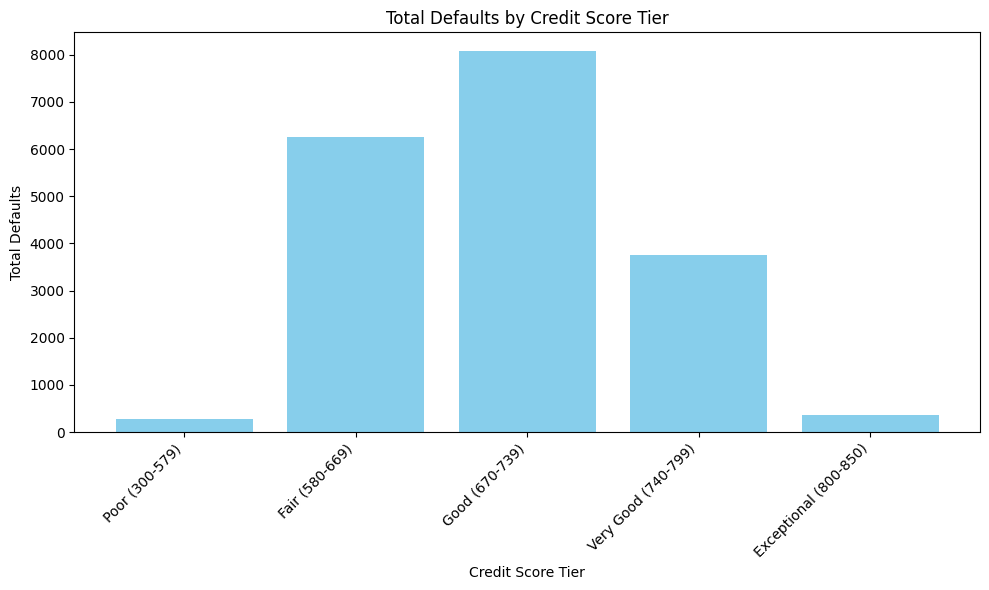

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(credit_risk_profile['credit_score_tier'], credit_risk_profile['total_defaults'], color='skyblue')
plt.xlabel('Credit Score Tier')
plt.ylabel('Total Defaults')
plt.title('Total Defaults by Credit Score Tier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This already shows us the proportion of credit score with which bankers have to be careful

Now we analyse default to loan to value and debt to income ratio and interest rate and loan size vs default rate as well so that they give us an idea about how vars behave and influence loan default behaviour

Text(0.5, 1.0, 'UPB')

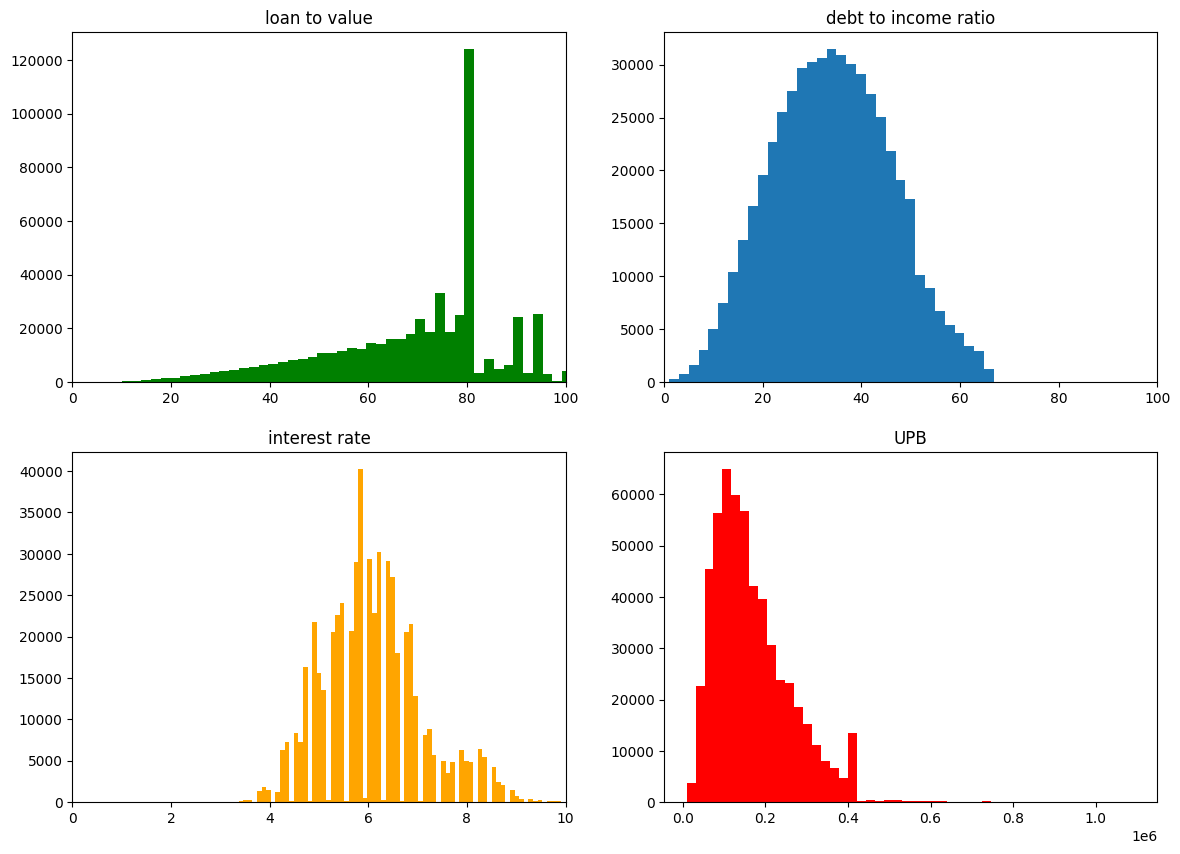

In [18]:
plt.figure(figsize=(14, 10)) 
plt.subplot(2, 2, 1)
plt.hist(og_df.og_ltv ,bins=500 ,color="Green")
plt.xlim(0,100)
plt.title("loan to value")

plt.subplot(2, 2, 2)
plt.hist(og_df.og_dti, bins = 500)
plt.xlim(0,100)
plt.title("debt to income ratio")

plt.subplot(2, 2, 3)
plt.hist(og_df.og_int_rate,bins=100, color="orange")
plt.xlim(0,10)
plt.title("interest rate")

plt.subplot(2, 2, 4)
plt.hist(og_df.og_upb, color="red", bins = 50)
plt.title("UPB")

In [19]:
import pandas as pd
import numpy as np

def vars_vs_default_independent(m_df, og_df):
    # -------------------------------------------------------------------------
    # 1. Isolate and Map Defaults (Kept as strings to prevent data type matching bugs)
    # -------------------------------------------------------------------------
    default_codes = [2,3,9,15]
    defaulted_loans = m_df[m_df["zero_balance_code"].isin(default_codes)]["loan_seq_no"].unique()
    
    # 2. Extract and Filter Features
    # FIX: Added "og_upb" to feature_cols so it isn't deleted during the slice!
    feature_cols = ["loan_seq_no", "og_ltv", "og_dti", "og_int_rate", "og_upb"]
    
    analysis_df = og_df[
        (og_df["og_ltv"].notna()) & (og_df["og_ltv"] > 0) &
        (og_df["og_dti"].notna()) & (og_df["og_dti"] > 0) &
        (og_df["og_int_rate"].notna()) & (og_df["og_int_rate"] > 0) &
        (og_df["og_upb"].notna()) & (og_df["og_upb"] > 0)
    ][feature_cols].copy()
    
    analysis_df["is_default"] = analysis_df["loan_seq_no"].isin(defaulted_loans).astype(int)
    
    # 3. Create the Distinct Tier Bins
    analysis_df["LTV"] = pd.cut(analysis_df["og_ltv"], bins=[0, 30, 55, 70, 85, 100], include_lowest=True)
    analysis_df["DTI"] = pd.cut(analysis_df["og_dti"], bins=[0, 20, 40, 60, 80, 100], include_lowest=True)
    analysis_df["Interest Rate"] = pd.cut(analysis_df["og_int_rate"], bins=[0, 2, 4, 6, 8, 10], include_lowest=True)
    
    # FIX/ADJUSTMENT: Assuming raw dollar amounts here. 
    # Adjust these numbers if your UPB is already normalized between 0 and 1!
    upb_bins = [0, 100000, 250000, 400000, 600000, 1000000] 
    analysis_df["UPB"] = pd.cut(analysis_df["og_upb"], bins=upb_bins, include_lowest=True)
    
    # -------------------------------------------------------------------------
    # 4. Process Each Factor Independently via a Loop
    # -------------------------------------------------------------------------
    factors = ["LTV", "DTI", "Interest Rate", "UPB"]
    summary_slices = []
    
    for factor in factors:
        slice_df = analysis_df.groupby(factor, observed=False).agg(
            total_loans=("is_default", "count"),
            total_defaults=("is_default", "sum")
        ).reset_index()
        
        slice_df = slice_df.rename(columns={factor: "risk_tier"})
        slice_df["risk_tier"] = slice_df["risk_tier"].astype(str)
        slice_df.insert(0, "factor", factor)
        summary_slices.append(slice_df)
        
    # -------------------------------------------------------------------------
    # 5. Stack the Independent Tables Vertically
    # -------------------------------------------------------------------------
    master_summary = pd.concat(summary_slices, ignore_index=True)
    master_summary["default_rate_pct"] = (master_summary["total_defaults"] / master_summary["total_loans"]) * 100
    
    return master_summary

# --- Execution ---
independent_risk_profile = vars_vs_default_independent(m_df, og_df)


In [20]:
independent_risk_profile

,factor,risk_tier,total_loans,total_defaults,default_rate_pct
0,LTV,"(-0.001, 30.0]",19826,46,0.232019
1,LTV,"(30.0, 55.0]",97318,731,0.751146
2,LTV,"(55.0, 70.0]",120072,2724,2.268639
3,LTV,"(70.0, 85.0]",239168,9689,4.051127
4,LTV,"(85.0, 100.0]",71878,5415,7.533599
5,DTI,"(-0.001, 20.0]",78240,1101,1.407209
6,DTI,"(20.0, 40.0]",287926,8429,2.927488
7,DTI,"(40.0, 60.0]",146222,7780,5.320677
8,DTI,"(60.0, 80.0]",7614,540,7.092199
9,DTI,"(80.0, 100.0]",0,0,NaN


C:\Temp\ipykernel_18952\1554648388.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "LTV"],
C:\Temp\ipykernel_18952\1554648388.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "DTI"],
C:\Temp\ipykernel_18952\1554648388.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "Interest Rate"],
C:\Temp\ipykernel_18952\1554648388.py:30: Futu

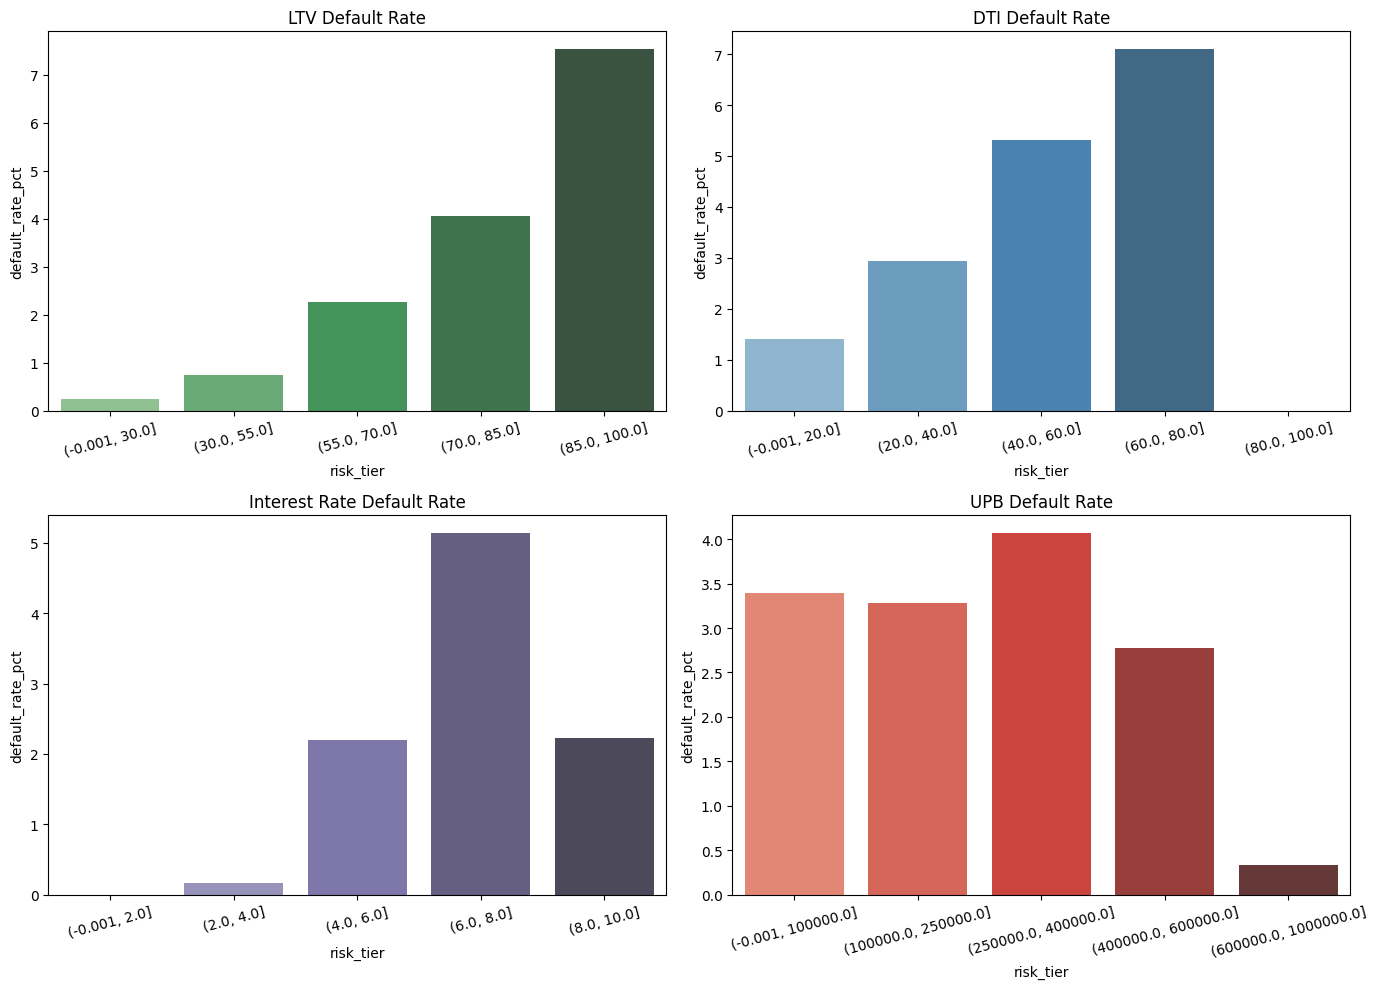

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the overall canvas size for a 2x2 grid
plt.figure(figsize=(14, 10))  

# --- Plot 1: Top Left ---
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, position 1
sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "LTV"], 
            x="risk_tier", y="default_rate_pct", palette="Greens_d")
plt.title("LTV Default Rate")
plt.xticks(rotation=15)

# --- Plot 2: Top Right ---
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, position 2
sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "DTI"], 
            x="risk_tier", y="default_rate_pct", palette="Blues_d")
plt.title("DTI Default Rate")
plt.xticks(rotation=15)

# --- Plot 3: Bottom Left ---
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, position 3
sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "Interest Rate"], 
            x="risk_tier", y="default_rate_pct", palette="Purples_d") # Swapped to Purples for variety!
plt.title("Interest Rate Default Rate")
plt.xticks(rotation=15)

# --- Plot 4: Bottom Right (FIXED) ---
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, position 4 (Fixed Capitalization)
sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "UPB"], 
            x="risk_tier", y="default_rate_pct", palette="Reds_d") # Fixed column name typos
plt.title("UPB Default Rate")
plt.xticks(rotation=15)

# Automatically adjust spacing so nothing overlaps
plt.tight_layout()
plt.show()

In [22]:
print(m_df.columns)
print(og_df.columns)

Index(['loan_seq_no', 'monthly_reporting_period', 'current_actual_upb',
       'current_loan_delinquency_status', 'loan_age',
       'remaining_months_to_legal_maturity', 'defect_settlement_date',
       'modification_flag', 'zero_balance_code', 'zero_balance_effective_date',
       'current_interest_rate', 'current_non_interest_bearing_upb', 'ddlpi',
       'mi_recoveries', 'net_sale_proceeds', 'non_mi_recoveries',
       'total_expenses', 'legal_costs', 'maintenance_and_preservation_costs',
       'taxes_and_insurance', 'miscellaneous_expenses',
       'actual_loss_calculation', 'cumulative_modification_cost',
       'interest_rate_step_indicator', 'payment_deferral_flag', 'eltv',
       'zero_balance_removal_upb', 'delinquent_accrued_interest',
       'delinquency_due_to_disaster', 'borrower_assistance_status_code',
       'current_month_modification_cost', 'interest_bearing_upb',
       'origination_year'],
      dtype='str')
Index(['cred_score', 'first_payment_date', 'first_time_h

Now we go to look for property's relation with Default rate

In [23]:
import pandas as pd
import numpy as np

def categorical_vars_vs_default(m_df, og_df):
    # -------------------------------------------------------------------------
    # 1. Isolate and Map Defaults
    # -------------------------------------------------------------------------
    default_codes = [2,3,9,15]
    defaulted_loans = m_df[m_df["zero_balance_code"].isin(default_codes)]["loan_seq_no"].unique()
    
    # Define the 5 target categorical features
    factors = [
        "loan_purpose",
        "no_of_borrowers",
        "first_time_homebuyer_flag",
        "occupancy_status",
        "prop_type"
    ]
    
    # 2. Extract and Filter Features (Dynamic non-null checks)
    feature_cols = ["loan_seq_no"] + factors
    
    # Drop rows where ANY of these 5 columns are missing/NaN
    analysis_df = og_df.dropna(subset=factors)[feature_cols].copy()
    
    # 3. Create the binary target variable (1 = defaulted, 0 = healthy)
    analysis_df["is_default"] = analysis_df["loan_seq_no"].isin(defaulted_loans).astype(int)
    
    # -------------------------------------------------------------------------
    # 4. Process Each Factor Independently via a Loop
    # -------------------------------------------------------------------------
    summary_slices = []
    
    for factor in factors:
        # Aggregate metrics for the current factor category
        slice_df = analysis_df.groupby(factor, observed=False).agg(
            total_loans=("is_default", "count"),
            total_defaults=("is_default", "sum")
        ).reset_index()
        
        # Rename the column category name to a unified column name for stacking
        slice_df = slice_df.rename(columns={factor: "risk_category"})
        
        # Force the category labels into a clean string to avoid type clashes
        slice_df["risk_category"] = slice_df["risk_category"].astype(str)
        
        # Inject metadata column at position 0 to track the originating factor
        slice_df.insert(0, "factor", factor)
        
        summary_slices.append(slice_df)
        
    # -------------------------------------------------------------------------
    # 5. Stack the Independent Summaries Vertically
    # -------------------------------------------------------------------------
    master_summary = pd.concat(summary_slices, ignore_index=True)
    
    # Calculate performance metrics across the entire final stacked output
    master_summary["default_rate_pct"] = (master_summary["total_defaults"] / master_summary["total_loans"]) * 100
    master_summary["portfolio_share_pct"] = (master_summary["total_loans"] / len(analysis_df)) * 100
    
    # Sort nicely by factor name and its internal default rate risk
    master_summary = master_summary.sort_values(by=["factor", "default_rate_pct"], ascending=[True, False]).reset_index(drop=True)
    
    return master_summary

# --- Execution ---
# Run the script using your master dataframes
categorical_risk_profile = categorical_vars_vs_default(m_df, og_df)



In [24]:
categorical_risk_profile

,factor,risk_category,total_loans,total_defaults,default_rate_pct,portfolio_share_pct
0,first_time_homebuyer_flag,Y,46531,2096,4.504524,8.460182
1,first_time_homebuyer_flag,N,503218,16669,3.312481,91.494182
2,first_time_homebuyer_flag,9,251,3,1.195219,0.045636
3,loan_purpose,C,164320,6953,4.231378,29.876364
4,loan_purpose,P,195085,6997,3.586642,35.470000
5,loan_purpose,N,190595,4818,2.527873,34.653636
6,no_of_borrowers,1,218810,11312,5.169782,39.783636
7,no_of_borrowers,2,331024,7456,2.252405,60.186182
8,no_of_borrowers,99,166,0,0.000000,0.030182
9,occupancy_status,I,25635,1464,5.710942,4.660909


In [26]:
# Calculate state_risk_profile for prop_state
default_codes = [2, 3, 9, 15]
defaulted_loans = m_df[m_df["zero_balance_code"].isin(default_codes)]["loan_seq_no"].unique()

factor = "prop_state"
feature_cols = ["loan_seq_no", factor]

analysis_df_state = og_df.dropna(subset=[factor])[feature_cols].copy()
analysis_df_state["is_default"] = analysis_df_state["loan_seq_no"].isin(defaulted_loans).astype(int)

state_risk_profile = analysis_df_state.groupby(factor, observed=False).agg(
    total_loans=("is_default", "count"),
    total_defaults=("is_default", "sum")
).reset_index()

state_risk_profile = state_risk_profile.rename(columns={factor: "risk_category"})
state_risk_profile["risk_category"] = state_risk_profile["risk_category"].astype(str)
state_risk_profile.insert(0, "factor", factor)
state_risk_profile["default_rate_pct"] = (state_risk_profile["total_defaults"] / state_risk_profile["total_loans"]) * 100

# Sort by default rate for better visualization
state_risk_profile = state_risk_profile.sort_values(by="default_rate_pct", ascending=False).reset_index(drop=True)

C:\Temp\ipykernel_18952\3717391696.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "loan_purpose"],
C:\Temp\ipykernel_18952\3717391696.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "no_of_borrowers"],
C:\Temp\ipykernel_18952\3717391696.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "first_time_homebuyer_flag"],
C:\Temp\ipyk

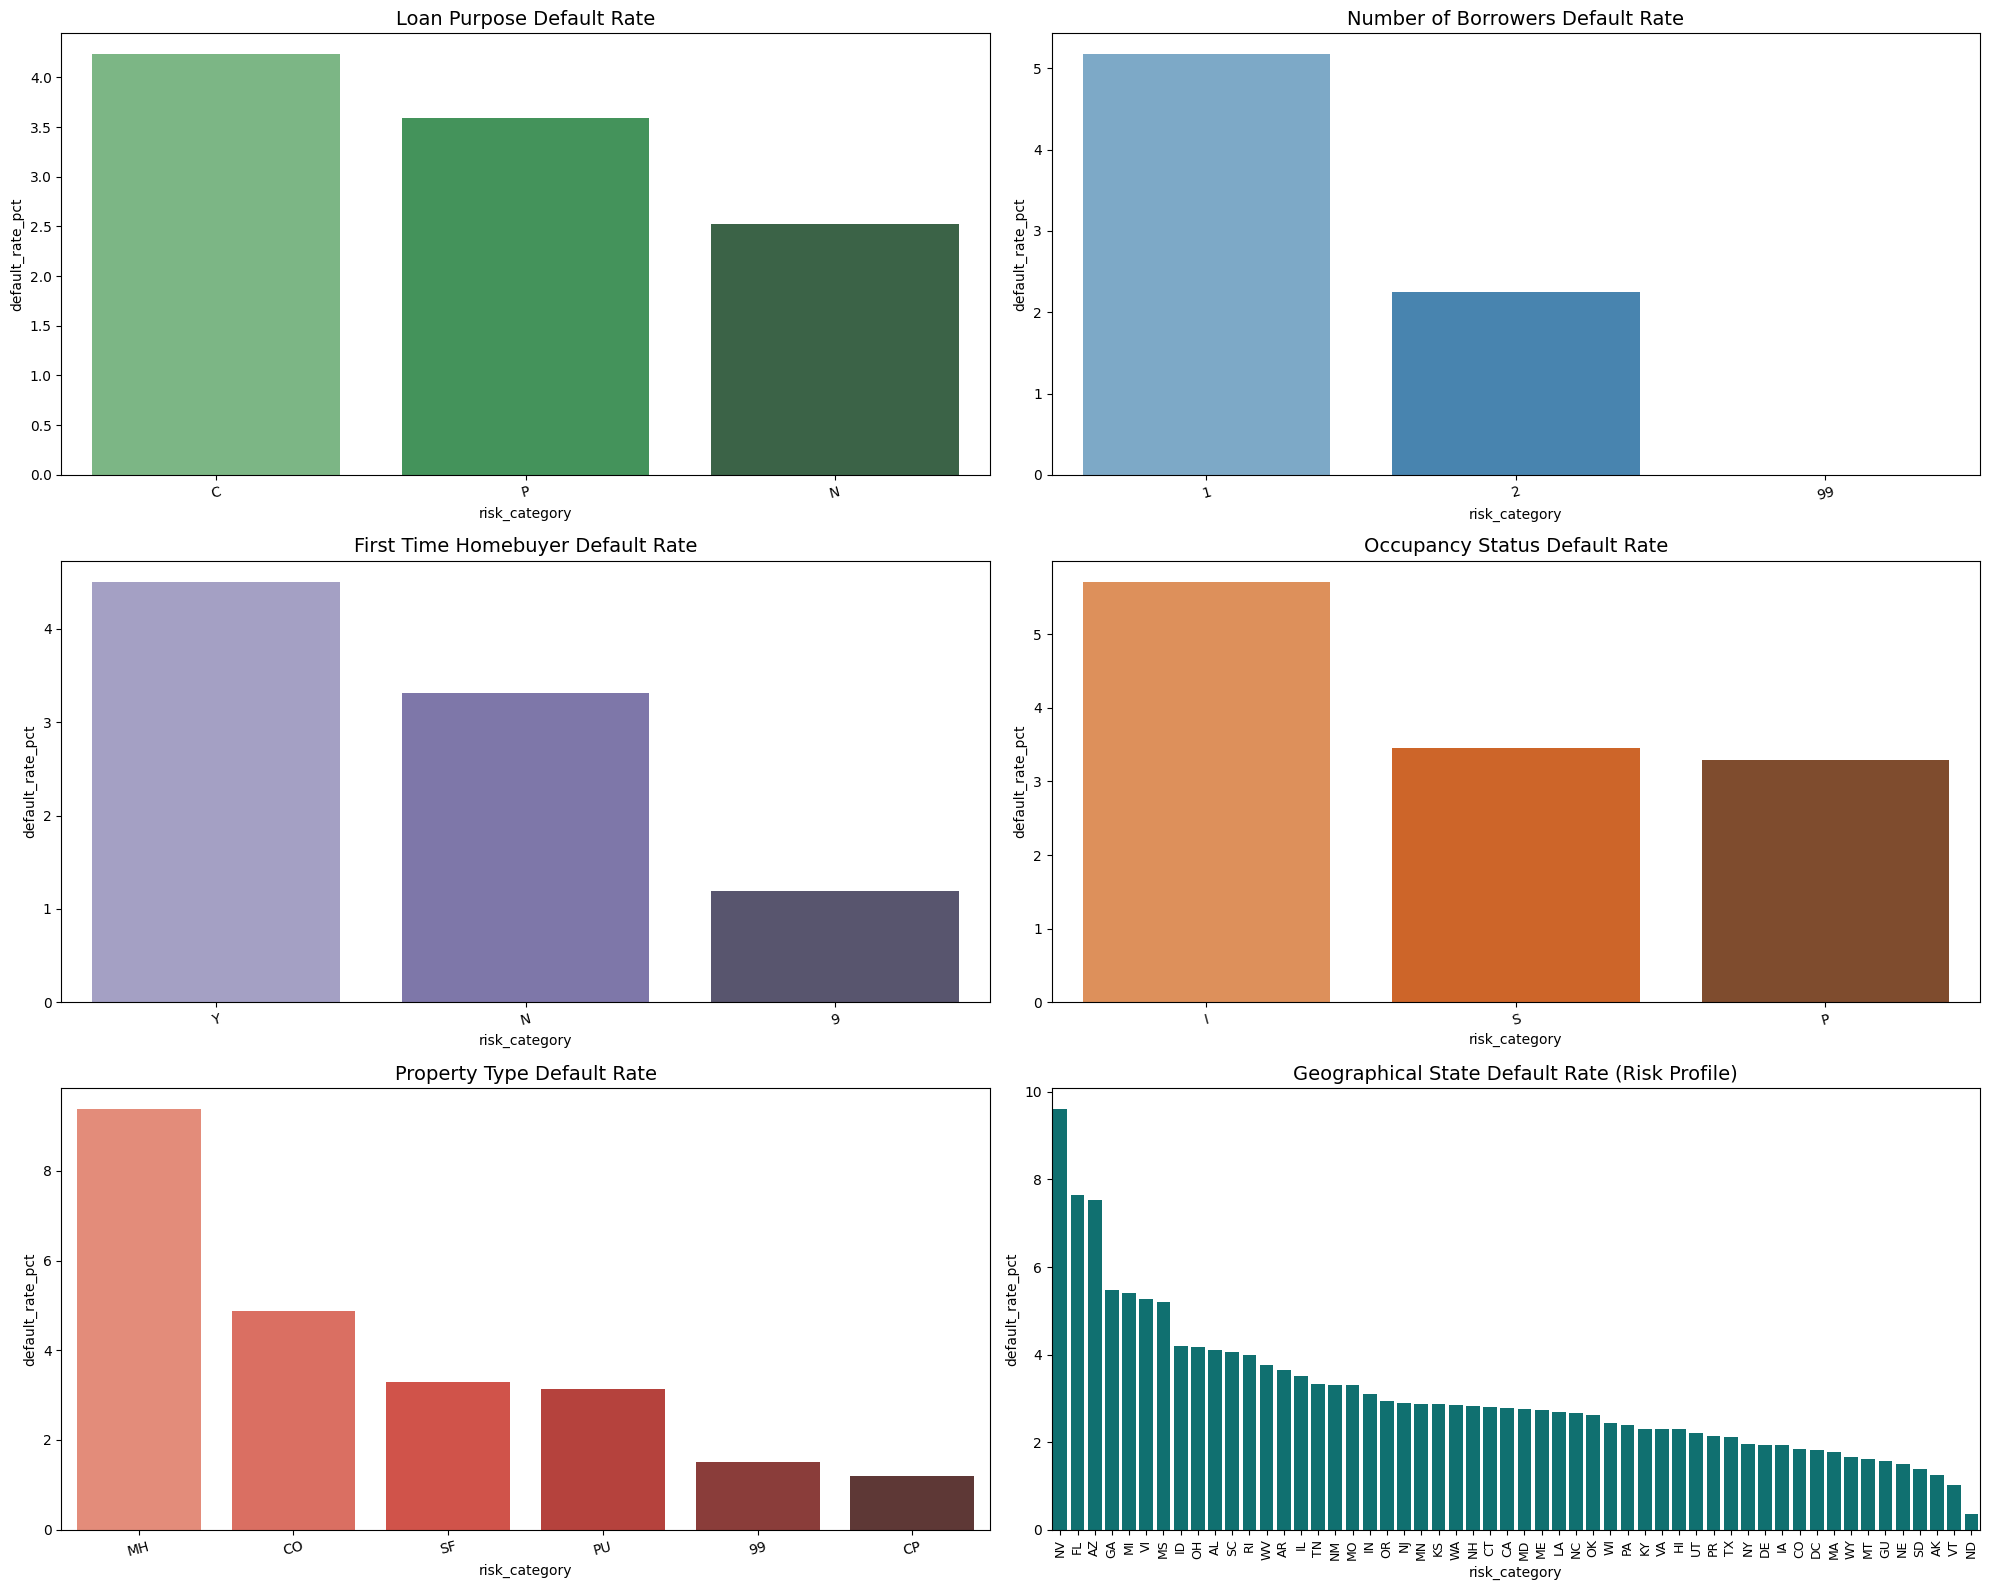

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# We expand the figure size globally to (20, 16) to give the entire grid massive breathing room
# This ensures the bottom plots, especially State, get that requested 20x10 feel.
plt.figure(figsize=(20, 16))  

# --- Plot 1: Top Left (loan_purpose) ---
plt.subplot(3, 2, 1)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "loan_purpose"], 
            x="risk_category", y="default_rate_pct", palette="Greens_d")
plt.title("Loan Purpose Default Rate", fontsize=14)
plt.xticks(rotation=15)

# --- Plot 2: Top Right (no_of_borrowers) ---
plt.subplot(3, 2, 2)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "no_of_borrowers"], 
            x="risk_category", y="default_rate_pct", palette="Blues_d")
plt.title("Number of Borrowers Default Rate", fontsize=14)
plt.xticks(rotation=15)

# --- Plot 3: Middle Left (first_time_homebuyer_flag) ---
plt.subplot(3, 2, 3)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "first_time_homebuyer_flag"], 
            x="risk_category", y="default_rate_pct", palette="Purples_d")
plt.title("First Time Homebuyer Default Rate", fontsize=14)
plt.xticks(rotation=15)

# --- Plot 4: Middle Right (occupancy_status) ---
plt.subplot(3, 2, 4)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "occupancy_status"], 
            x="risk_category", y="default_rate_pct", palette="Oranges_d")
plt.title("Occupancy Status Default Rate", fontsize=14)
plt.xticks(rotation=15)

# --- Plot 5: Bottom Left (prop_type) ---
plt.subplot(3, 2, 5)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "prop_type"], 
            x="risk_category", y="default_rate_pct", palette="Reds_d")
plt.title("Property Type Default Rate", fontsize=14)
plt.xticks(rotation=15)

# --- Plot 6: Bottom Right (prop_state) ---
# This slot will inherit the massive bottom-row width of the 20-inch wide canvas
plt.subplot(3, 2, 6)  


sns.barplot(data=state_risk_profile,
            x="risk_category", y="default_rate_pct", color="teal")
plt.title("Geographical State Default Rate (Risk Profile)", fontsize=14)

# CRITICAL FOR STATES: Rotate labels 90 degrees and shrink font size so all 50 states fit cleanly!
plt.xticks(rotation=90, fontsize=9) 

# Automatically clean up spacing across the giant canvas
plt.tight_layout()
plt.show()

Now we do some corr Analysis

In [28]:
og_df.cred_score

0         790
1         771
2         762
3         737
4         594
         ... 
549995    808
549996    824
549997    785
549998    717
549999    791
Name: cred_score, Length: 550000, dtype: int64

In [29]:
vars_matrix = pd.DataFrame(og_df[["cred_score",
"og_ltv",
"og_cltv",
"og_dti",
"og_upb",
"og_int_rate",
"og_loan_term"]])
corr_matrix = vars_matrix.corr()
corr_matrix


,cred_score,og_ltv,og_cltv,og_dti,og_upb,og_int_rate,og_loan_term
cred_score,1.000000,-0.017728,-0.019783,-0.005201,-0.007107,0.027932,-0.010140
og_ltv,-0.017728,1.000000,0.959935,0.027222,0.087050,0.168832,0.265057
og_cltv,-0.019783,0.959935,1.000000,0.055108,0.112536,0.146354,0.273212
og_dti,-0.005201,0.027222,0.055108,1.000000,0.055683,-0.158141,0.004923
og_upb,-0.007107,0.087050,0.112536,0.055683,1.000000,-0.225784,0.221698
og_int_rate,0.027932,0.168832,0.146354,-0.158141,-0.225784,1.000000,0.265113
og_loan_term,-0.010140,0.265057,0.273212,0.004923,0.221698,0.265113,1.000000


In [30]:
# Returns a single float value between -1 and 1
ltv_dti_corr = og_df["og_ltv"].corr(og_df["og_dti"])
print(f"Correlation between LTV and DTI: {ltv_dti_corr}")

Correlation between LTV and DTI: 0.027221684135984536


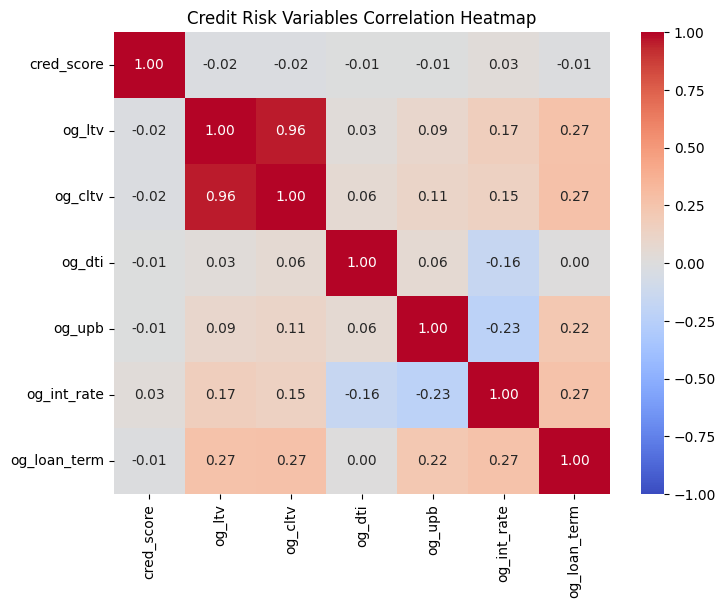

In [31]:


plt.figure(figsize=(8, 6))

# 'annot=True' prints the actual correlation numbers inside the colored boxes
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f", 
            vmin=-1, 
            vmax=1)

plt.title("Credit Risk Variables Correlation Heatmap")
plt.show()

In [32]:
m_df

,loan_seq_no,monthly_reporting_period,current_actual_upb,current_loan_delinquency_status,loan_age,remaining_months_to_legal_maturity,defect_settlement_date,modification_flag,zero_balance_code,zero_balance_effective_date,...,interest_rate_step_indicator,payment_deferral_flag,eltv,zero_balance_removal_upb,delinquent_accrued_interest,delinquency_due_to_disaster,borrower_assistance_status_code,current_month_modification_cost,interest_bearing_upb,origination_year
0,F00Q10000035,200210,101000.00,0,0,329.0,NaN,N,NaN,NaN,...,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,101000.00,2000
1,F00Q10000035,200211,101000.00,0,1,328.0,NaN,N,NaN,NaN,...,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,101000.00,2000
2,F00Q10000035,200212,101000.00,0,2,327.0,NaN,N,NaN,NaN,...,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,101000.00,2000
3,F00Q10000035,200301,101000.00,0,3,326.0,NaN,N,NaN,NaN,...,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,101000.00,2000
4,F00Q10000035,200302,100000.00,0,4,325.0,NaN,N,NaN,NaN,...,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,100000.00,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33058386,F10Q40595389,202002,83674.02,0,102,258.0,NaN,N,NaN,NaN,...,NaN,N,25.0,NaN,NaN,NaN,NaN,NaN,83674.02,2010
33058387,F10Q40595389,202003,83481.11,0,103,257.0,NaN,N,NaN,NaN,...,NaN,N,25.0,NaN,NaN,NaN,NaN,NaN,83481.11,2010
33058388,F10Q40595389,202004,83287.47,0,104,256.0,NaN,N,NaN,NaN,...,NaN,N,25.0,NaN,NaN,NaN,NaN,NaN,83287.47,2010
33058389,F10Q40595389,202005,83093.11,0,105,255.0,NaN,N,NaN,NaN,...,NaN,N,24.0,NaN,NaN,NaN,NaN,NaN,83093.11,2010


In [36]:
m_df.current_loan_delinquency_status.nunique()

204


--- MONTHLY PERFORMANCE DELINQUENCY PROFILE ---
                          Monthly_Records Percentage_Share
delinquency_bucket                                        
Current                        31,590,652         95.5602%
30 DPD                            578,180          1.7490%
60 DPD                            181,713          0.5497%
90-179 DPD                        197,490          0.5974%
180+ DPD / Severe Default         510,356          1.5438%
Missing/Unknown                       NaN              NaN


C:\Temp\ipykernel_18952\829300341.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delq_summary.index, y=delq_summary["Monthly_Records"], palette="magma")


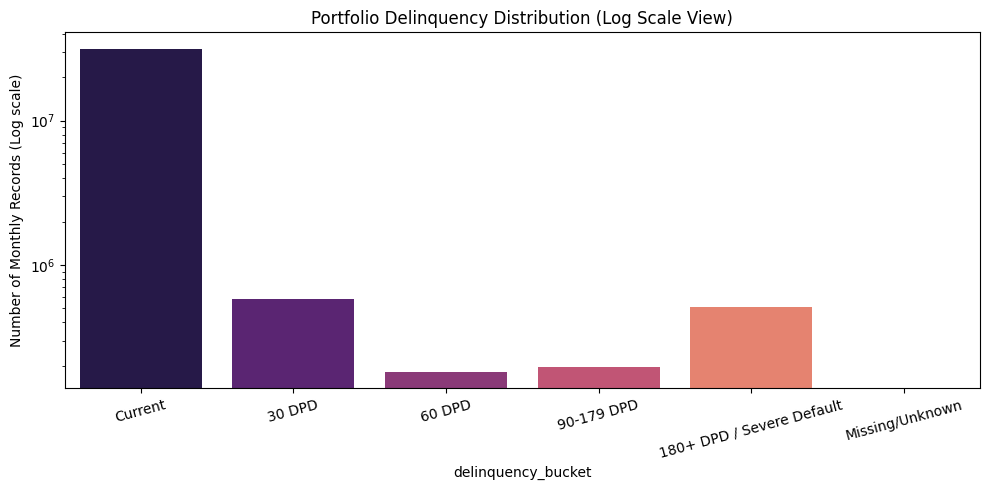

In [33]:
# 1. Standardize the delinquency column to strings to handle mixed types cleanly
m_df["current_loan_delinquency_status"] = m_df["current_loan_delinquency_status"].astype(str).str.strip()

# 2. Define a quick mapping function to categorize the raw codes into readable risk buckets
def map_delinquency(status):
    if status in ["0", "0.0"]:
        return "Current"
    elif status in ["1", "1.0"]:
        return "30 DPD"
    elif status in ["2", "2.0"]:
        return "60 DPD"
    elif status in ["3", "4", "5", "3.0", "4.0", "5.0"]:
        return "90-179 DPD"
    elif status in ["unknown", "nan", "None", "XX"]:
        return "Missing/Unknown"
    else:
        return "180+ DPD / Severe Default"

# Apply the mapping across every row in your massive monthly file
m_df["delinquency_bucket"] = m_df["current_loan_delinquency_status"].apply(map_delinquency)

# 3. Calculate absolute counts and normalized percentages across the entire time-series portfolio
delq_counts = m_df["delinquency_bucket"].value_counts()
delq_pct = m_df["delinquency_bucket"].value_counts(normalize=True) * 100

# 4. Combine into a clean summary table
delq_summary = pd.DataFrame({
    "Monthly_Records": delq_counts,
    "Percentage_Share": delq_pct
}).reindex(["Current", "30 DPD", "60 DPD", "90-179 DPD", "180+ DPD / Severe Default", "Missing/Unknown"])

print("\n--- MONTHLY PERFORMANCE DELINQUENCY PROFILE ---")
print(delq_summary.to_string(formatters={"Monthly_Records": "{:,.0f}".format, "Percentage_Share": "{:.4f}%".format}))

# 5. Plot the Delinquency Distribution on a log scale 
# (Log scale is critical because 'Current' is so massive it will swallow the other bars otherwise)
plt.figure(figsize=(10, 5))
sns.barplot(x=delq_summary.index, y=delq_summary["Monthly_Records"], palette="magma")
plt.yscale("log") 
plt.title("Portfolio Delinquency Distribution (Log Scale View)")
plt.ylabel("Number of Monthly Records (Log scale)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [37]:


# 1. Isolate the target defaults using string codes from the monthly file
default_codes = [2,3,9,15]
defaulted_loans = m_df[m_df["zero_balance_code"].isin(default_codes)]["loan_seq_no"].unique()

# 2. Explicitly map the binary target column globally inside og_df
og_df["is_default"] = og_df["loan_seq_no"].isin(defaulted_loans).astype(int)

print("Target variable 'is_default' mapped successfully to og_df!")
print(og_df["is_default"].value_counts())

Target variable 'is_default' mapped successfully to og_df!
is_default
0    531232
1     18768
Name: count, dtype: int64


C:\Temp\ipykernel_18952\3253775778.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=og_df[og_df["cred_score"] <= 850], x="is_default", y="cred_score", palette="Set2")
C:\Temp\ipykernel_18952\3253775778.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=og_df, x="is_default", y="og_ltv", palette="Set2")
C:\Temp\ipykernel_18952\3253775778.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=og_df[og_df["og_dti"] < 999], x="is_default", y="og_dti", palette="Set2")
C:\Temp\ipykernel_18952\3253775778.py:28: FutureWarn

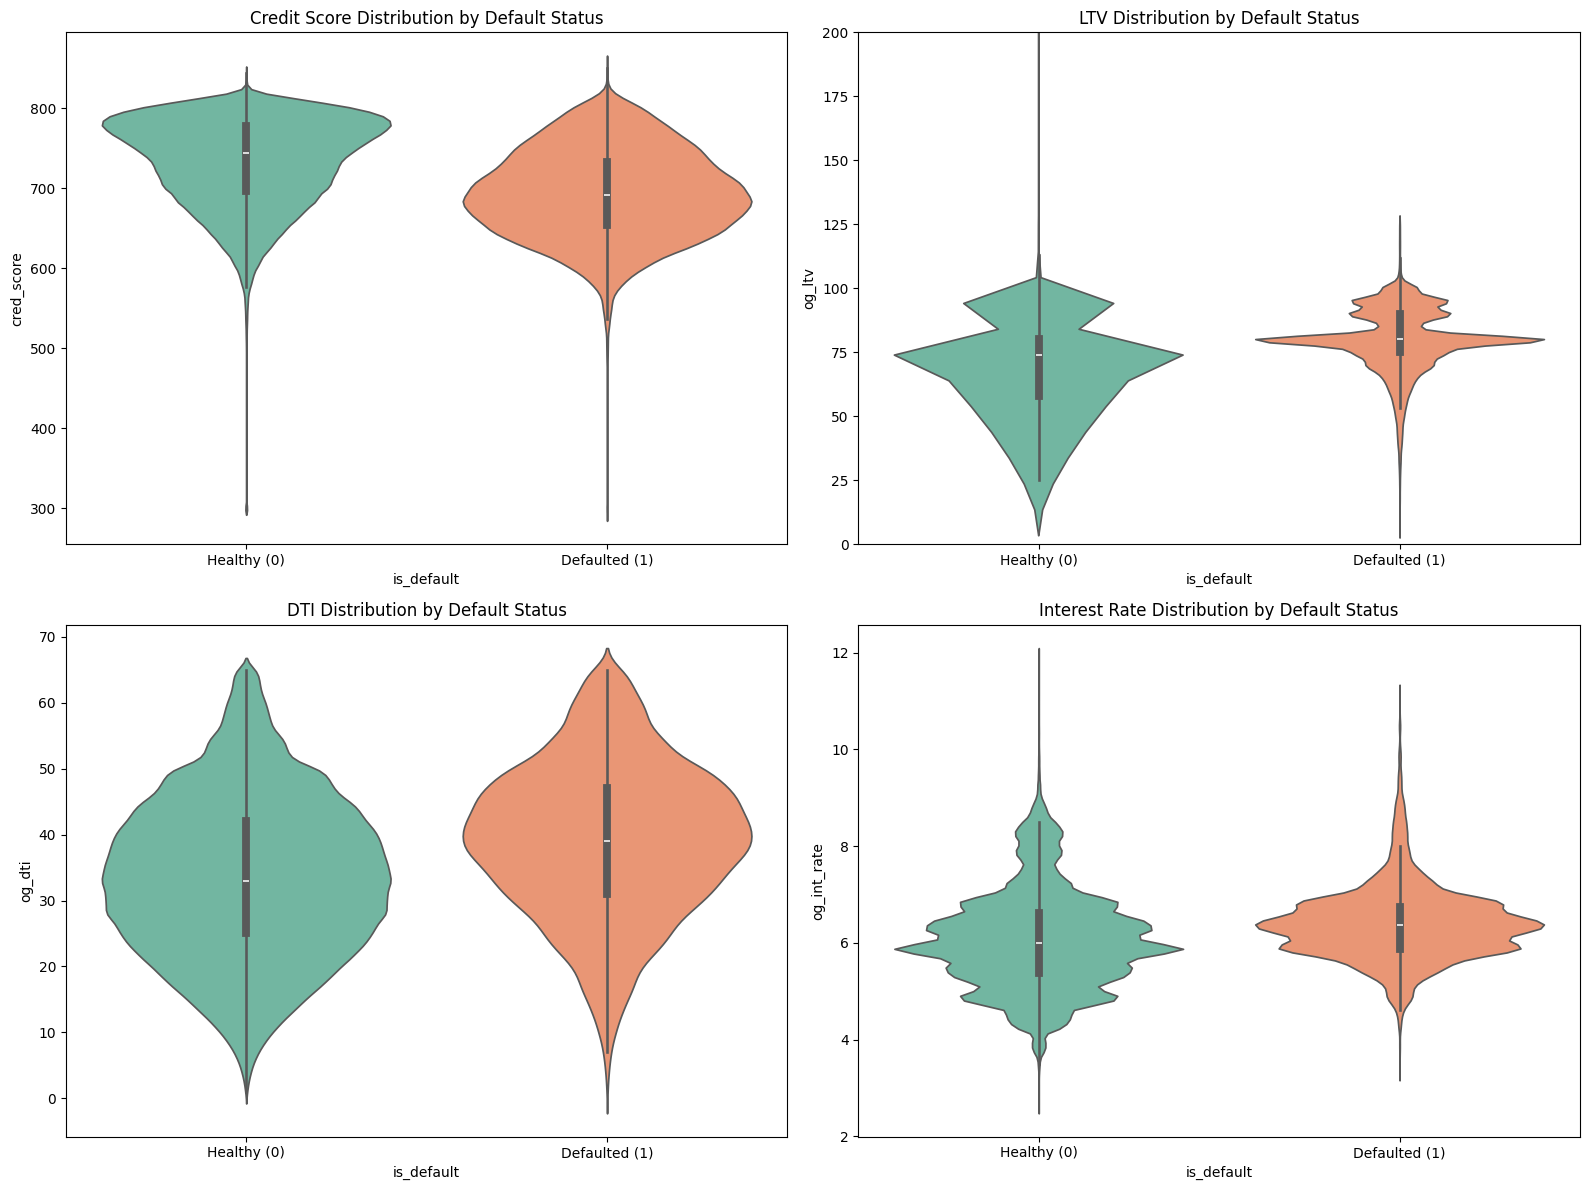

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

# Plot 1: Credit Score (dropping FICO missing value placeholders)
plt.subplot(2, 2, 1)
sns.violinplot(data=og_df[og_df["cred_score"] <= 850], x="is_default", y="cred_score", palette="Set2")
plt.title("Credit Score Distribution by Default Status")
plt.xticks([0, 1], ["Healthy (0)", "Defaulted (1)"])

# Plot 2: Original LTV
plt.subplot(2, 2, 2)
sns.violinplot(data=og_df, x="is_default", y="og_ltv", palette="Set2")
plt.title("LTV Distribution by Default Status")
plt.xticks([0, 1], ["Healthy (0)", "Defaulted (1)"])
plt.ylim(0,200)

# Plot 3: Original DTI (dropping Freddie Mac's 999 placeholder)
plt.subplot(2, 2, 3)
sns.violinplot(data=og_df[og_df["og_dti"] < 999], x="is_default", y="og_dti", palette="Set2")
plt.title("DTI Distribution by Default Status")
plt.xticks([0, 1], ["Healthy (0)", "Defaulted (1)"])


# Plot 4: Original Interest Rate
plt.subplot(2, 2, 4)
sns.violinplot(data=og_df, x="is_default", y="og_int_rate", palette="Set2")
plt.title("Interest Rate Distribution by Default Status")
plt.xticks([0, 1], ["Healthy (0)", "Defaulted (1)"])

plt.tight_layout()
plt.show()

In [42]:
# 1. Keep valid, non-placeholder FICO records
clean_fico_df = og_df[(og_df["cred_score"].notna()) & (og_df["cred_score"] <= 850)].copy()

# 2. Slice into 10 equal-count deciles
clean_fico_df["fico_decile"] = pd.qcut(clean_fico_df["cred_score"], q=10, labels=False) + 1

# 3. Aggregation loop using our new dataframe naming convention
decile_summary = clean_fico_df.groupby("fico_decile").agg(
    min_score=("cred_score", "min"),
    max_score=("cred_score", "max"),
    total_loans=("is_default", "count"),
    total_defaults=("is_default", "sum")
).reset_index()

decile_summary["default_rate_pct"] = (decile_summary["total_defaults"] / decile_summary["total_loans"]) * 100

print("\n" + "="*20 + " CREDIT SCORE DECILE RISK TABLE " + "="*20)
print(decile_summary.to_string(index=False, formatters={
    "total_loans": "{:,}".format, 
    "total_defaults": "{:,}".format, 
    "default_rate_pct": "{:.2f}%".format
}))


==================== CREDIT SCORE DECILE RISK TABLE ====================
 fico_decile  min_score  max_score total_loans total_defaults default_rate_pct
           1        300        654      55,905          4,766            8.53%
           2        655        683      54,981          3,564            6.48%
           3        684        705      55,539          2,793            5.03%
           4        706        724      53,960          2,081            3.86%
           5        725        742      55,547          1,639            2.95%
           6        743        757      53,596          1,264            2.36%
           7        758        771      57,948            936            1.62%
           8        772        783      54,484            683            1.25%
           9        784        795      51,793            483            0.93%
          10        796        850      54,653            530            0.97%


In [43]:
print("\n" + "="*20 + " CATEGORICAL CROSS-TABULATION " + "="*20)

# Cross table for Occupancy Status using og_df
occupancy_cross = pd.crosstab(
    index=og_df["occupancy_status"], 
    columns=og_df["is_default"], 
    margins=True,            
    normalize="index"        
) * 100

print("\nOccupancy Status Default Distribution (%):")
print(occupancy_cross.round(2).to_string())

# Cross table for Loan Purpose using og_df
purpose_cross = pd.crosstab(
    index=og_df["loan_purpose"], 
    columns=og_df["is_default"], 
    margins=True, 
    normalize="index"
) * 100

print("\nLoan Purpose Default Distribution (%):")
print(purpose_cross.round(2).to_string())


==================== CATEGORICAL CROSS-TABULATION ====================

Occupancy Status Default Distribution (%):
is_default            0     1
occupancy_status             
I                 94.29  5.71
P                 96.71  3.29
S                 96.55  3.45
All               96.59  3.41

Loan Purpose Default Distribution (%):
is_default        0     1
loan_purpose             
C             95.77  4.23
N             97.47  2.53
P             96.41  3.59
All           96.59  3.41


In [49]:

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select the continuous numeric features you intend to model
vif_features = ["cred_score", "og_ltv", "og_dti", "og_int_rate", "og_upb",]

# 2. Clean out missing rows or Freddie Mac placeholder codes (999/9999)
vif_df = og_df[
    (og_df["cred_score"].notna()) & (og_df["cred_score"] <= 850) &
    (og_df["og_dti"].notna()) & (og_df["og_dti"] < 999) &
    (og_df["og_ltv"].notna()) & (og_df["og_ltv"] > 0) &
    (og_df["og_int_rate"].notna()) & (og_df["og_int_rate"] > 0) &
    (og_df["og_upb"].notna()) & (og_df["og_upb"] > 0)
][vif_features].copy()

# 3. Add a constant column (intercept) - Intercept is mathematically required for VIF calculations!
vif_df['intercept'] = 1.0

# 4. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = vif_features
vif_data["VIF"] = [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_features))]

print("--- VARIANCE INFLATION FACTOR (VIF) RESULTS ---")
print(vif_data.round(2).to_string(index=False))

--- VARIANCE INFLATION FACTOR (VIF) RESULTS ---
    feature  VIF
 cred_score 1.13
     og_ltv 1.09
     og_dti 1.07
og_int_rate 1.17
     og_upb 1.10


In [50]:
import scipy.stats as stats

# 1. Isolate the credit scores for both target classes
healthy_fico = og_df[(og_df["is_default"] == 0) & (og_df["cred_score"] <= 850)]["cred_score"].dropna()
defaulted_fico = og_df[(og_df["is_default"] == 1) & (og_df["cred_score"] <= 850)]["cred_score"].dropna()

print("--- NUMERICAL FEATURE SIGNIFICANCE (CREDIT SCORE) ---")
print(f"Mean FICO (Healthy): {healthy_fico.mean():.1f}")
print(f"Mean FICO (Defaulted): {defaulted_fico.mean():.1f}\n")

# 2. Execute Parametric T-Test
t_stat, t_p_val = stats.ttest_ind(healthy_fico, defaulted_fico, equal_var=False)
print(f"T-Test Statistic: {t_stat:.4f} | P-Value: {t_p_val}")

# 3. Execute Non-Parametric Mann-Whitney U Test
u_stat, u_p_val = stats.mannwhitneyu(healthy_fico, defaulted_fico, alternative='two-sided')
print(f"Mann-Whitney U Stat: {u_stat:,} | P-Value: {u_p_val}")

# Interpretation rule of thumb
if u_p_val < 0.05:
    print("\n (Conclusion): Statistically Significant! The difference in credit scores is real.")
else:
    print("\n (Conclusion): Not Significant. The difference could be due to random chance.")

--- NUMERICAL FEATURE SIGNIFICANCE (CREDIT SCORE) ---
Mean FICO (Healthy): 733.2
Mean FICO (Defaulted): 693.1

T-Test Statistic: 97.1225 | P-Value: 0.0
Mann-Whitney U Stat: 6,991,462,215.5 | P-Value: 0.0

 (Conclusion): Statistically Significant! The difference in credit scores is real.


In [51]:
import scipy.stats as stats
import pandas as pd

print("--- CATEGORICAL FEATURE SIGNIFICANCE (CHI-SQUARE) ---")

# 1. Generate a raw count contingency table (Do NOT normalize here!)
contingency_matrix = pd.crosstab(og_df["occupancy_status"], og_df["is_default"])

# 2. Run the Chi-Square test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_matrix)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_val}")
print(f"Degrees of Freedom: {dof}")

# Interpretation
if p_val < 0.05:
    print("\n(Conclusion): Statistically Significant! Occupancy status is strongly associated with default risk.")
else:
    print("\n (Conclusion): Not Significant. No statistical connection found.")

--- CATEGORICAL FEATURE SIGNIFICANCE (CHI-SQUARE) ---
Chi-Square Statistic: 432.7250
P-Value: 1.0838131090272377e-94
Degrees of Freedom: 2

(Conclusion): Statistically Significant! Occupancy status is strongly associated with default risk.


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

#==========================================================================
#OPTIONAL
#==========================================================================

# 1. Setup variables and clean dataset for analysis
target = "is_default"
continuous_features = ["cred_score", "og_ltv", "og_dti", "og_int_rate", "og_upb"]

# Filter out missing values and known Freddie Mac numeric placeholders
eda_clean_df = og_df[
    (og_df[target].notna()) &
    (og_df["cred_score"] <= 850) &
    (og_df["og_dti"] < 999) &
    (og_df["og_ltv"] <= 150)  # Caps crazy outliers seen in violin plot
].copy()

# =========================================================================
# MODULE 1: WEIGHT OF EVIDENCE (WoE) & INFORMATION VALUE (IV) FUNCTIONS
# =========================================================================

def calculate_woe_iv_binned(df, feature, target, num_bins=10):
    """
    Slices a continuous feature into equal-frequency quantiles (qcut),
    computes the WoE for each bin, and returns the total Information Value (IV).
    """
    # Create copy to protect original data
    working_df = pd.DataFrame({
        'feature': df[feature],
        'target': df[target]
    })
    
    # Bin continuous variables into deciles using qcut. 
    # duplicates='drop' handles cases where certain values repeat heavily.
    working_df['bin'] = pd.qcut(working_df['feature'], q=num_bins, duplicates='drop')
    
    # Generate contingency table
    ct = pd.crosstab(working_df['bin'], working_df['target'], margins=False)
    ct.columns = ['Good', 'Bad']  # Assumes 0=Good, 1=Bad
    
    # Apply minor smoothing correction (0.5) to completely eliminate division by zero/log errors
    ct['Good'] = ct['Good'] + 0.5
    ct['Bad'] = ct['Bad'] + 0.5
    
    # Calculate percentage shares
    total_goods = ct['Good'].sum()
    total_bads = ct['Bad'].sum()
    
    ct['Pct_Good'] = ct['Good'] / total_goods
    ct['Pct_Bad'] = ct['Bad'] / total_bads
    
    # Calculate WoE and individual Bin IVs
    ct['WoE'] = np.log(ct['Pct_Good'] / ct['Pct_Bad'])
    ct['IV_bin'] = (ct['Pct_Good'] - ct['Pct_Bad']) * ct['WoE']
    
    total_iv = ct['IV_bin'].sum()
    return ct[['WoE', 'IV_bin']], total_iv

# Initialize dictionary to collect total IV results
iv_summary_dict = {}

print("="*20 + " DETAIL: WEIGHT OF EVIDENCE (WoE) SPLITS " + "="*20)
for col in continuous_features:
    detail_table, total_iv = calculate_woe_iv_binned(eda_clean_df, col, target, num_bins=10)
    iv_summary_dict[col] = total_iv
    
    print(f"\n🔹 Feature: {col} | Overall IV: {total_iv:.4f}")
    print(detail_table.round(4).to_string())
    print("-" * 65)

# Convert IV results to a sorted DataFrame
iv_df = pd.DataFrame(list(iv_summary_dict.items()), columns=['Feature', 'Information_Value'])
iv_df = iv_df.sort_values(ascending=False, by='Information_Value')


# =========================================================================
# MODULE 2: MUTUAL INFORMATION (MI) CALCULATION
# =========================================================================

X_mi = eda_clean_df[continuous_features]
y_mi = eda_clean_df[target]

# Compute non-parametric mutual info classification scores
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_df = pd.DataFrame({
    'Feature': continuous_features,
    'Mutual_Information': mi_scores
}).sort_values(ascending=False, by='Mutual_Information')


# =========================================================================
# FINAL COMPARISON REPORT
# =========================================================================

print("\n" + "="*23 + " FINAL MODEL SELECTION REPORT " + "="*23)

# Merge frameworks together for easier interpretation
final_report = pd.merge(iv_df, mi_df, on='Feature')

# Map regulatory bank rule definitions onto your IV matrix data
def assign_iv_interpretation(val):
    if val < 0.02: return "Unpredictable (Drop)"
    elif val <= 0.10: return "Weak Predictor"
    elif val <= 0.30: return "Medium Predictor"
    elif val <= 0.50: return "Strong Predictor (Keep)"
    else: return "Suspicious / Check Leakage"

final_report['Bank_Risk_Rule'] = final_report['Information_Value'].apply(assign_iv_interpretation)
print(final_report.to_string(index=False))

==================== DETAIL: WEIGHT OF EVIDENCE (WoE) SPLITS ====================

🔹 Feature: cred_score | Overall IV: 0.5558
                     WoE  IV_bin
bin                             
(299.999, 653.0] -0.9647  0.1494
(653.0, 682.0]   -0.6775  0.0640
(682.0, 704.0]   -0.4214  0.0221
(704.0, 723.0]   -0.1218  0.0016
(723.0, 741.0]    0.1537  0.0022
(741.0, 756.0]    0.3804  0.0119
(756.0, 770.0]    0.7593  0.0431
(770.0, 782.0]    1.0363  0.0678
(782.0, 795.0]    1.3362  0.1016
(795.0, 850.0]    1.3027  0.0921
-----------------------------------------------------------------

🔹 Feature: og_ltv | Overall IV: 0.5289
                  WoE  IV_bin
bin                          
(5.999, 43.0]  2.0645  0.1933
(43.0, 54.0]   1.4120  0.1061
(54.0, 63.0]   0.8176  0.0505
(63.0, 69.0]   0.3471  0.0094
(69.0, 75.0]  -0.0583  0.0005
(75.0, 79.0]  -0.0585  0.0003
(79.0, 80.0]  -0.2375  0.0147
(80.0, 90.0]  -0.7351  0.0631
(90.0, 102.0] -0.9388  0.0910
------------------------------------------

In [59]:
import numpy as np
import pandas as pd

print("\n" + "=" * 20 + " STARTING LEVEL 9: TIME-BASED EDA " + "=" * 20)

# Rename variable reference to match your exact column name
og_df["orig_year"] = og_df["origination_year"]

# --- SECTION 1: DEFAULT RATE BY ORIGINATION YEAR (VINTAGE ANALYSIS) ---
print("\n📊 Section 1: Default Rate by Origination Year (Vintage Analysis)")
vintage_risk = og_df.groupby("orig_year")["is_default"].agg(
    ["count", "sum", "mean"]
)
vintage_risk.columns = ["Total_Loans", "Total_Defaults", "Default_Rate (%)"]
vintage_risk["Default_Rate (%)"] = vintage_risk["Default_Rate (%)"] * 100

print(vintage_risk.round(2).to_string())


# --- SECTION 2: PORTFOLIO DETERIORATION MATRIX (90+ DPD OVER TIME) ---
print("\n📊 Section 2: Building Vintage Cohort Deterioration Matrix...")

# Merge origination context from og_df into longitudinal performance tracking from m_df
performance_panel = pd.merge(
    m_df[["loan_seq_no", "monthly_reporting_period", "current_loan_delinquency_status"]],
    og_df[["loan_seq_no", "orig_year"]],
    on="loan_seq_no", # Corrected from 'loan_id' to 'loan_seq_no'
    how="inner",
)

# Convert performance periods to datetime to extract tracking year and month
performance_panel["monthly_reporting_period"] = pd.to_datetime(
    performance_panel["monthly_reporting_period"]
)

# Calculate Months On Books (MOB) using the performance date vs the loan's birth year
# Assuming standard start month of January (0) for simplicity in raw year baselines
performance_panel["MOB"] = (
    (performance_panel["monthly_reporting_period"].dt.year - performance_panel["orig_year"]) * 12 + 
    (performance_panel["monthly_reporting_period"].dt.month - 1)
)

# Filter out edge-case anomalies and focus strictly on the standard 3-year performance horizon
performance_panel = performance_panel[
    (performance_panel["MOB"] >= 0) & (performance_panel["MOB"] <= 36)
]

# Clean delinquency column: force strings (like 'R' or 'X') to NaN, fill with 0, cast to integer
performance_panel["delinq_numeric"] = (
    pd.to_numeric(
        performance_panel["current_loan_delinquency_status"], errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

# Flag Serious Delinquency status (3 or more missed payments = 90+ DPD)
performance_panel["is_90_plus"] = np.where(
    performance_panel["delinq_numeric"] >= 3, 1, 0
)

# Construct the formal Credit Risk Vintage Cohort Pivot Table
cohort_matrix = (
    performance_panel.pivot_table(
        index="orig_year", columns="MOB", values="is_90_plus", aggfunc="mean"
    )
    * 100
)

print("\n📈 Portfolio Deterioration Matrix (90+ DPD Rate % by Months On Books):")

# Target specific critical seasonal intervals (0, 6, 12, 18, 24, 30, 36 MOB) for easy review
available_mobs = [
    m for m in [0, 6, 12, 18, 24, 30, 36] if m in cohort_matrix.columns
]
print(cohort_matrix[available_mobs].round(2).to_string())


==================== STARTING LEVEL 9: TIME-BASED EDA ====================

📊 Section 1: Default Rate by Origination Year (Vintage Analysis)
           Total_Loans  Total_Defaults  Default_Rate (%)
orig_year                                               
2000             50000             653              1.31
2001             50000             603              1.21
2002             50000             668              1.34
2003             50000             731              1.46
2004             50000            1545              3.09
2005             50000            2850              5.70
2006             50000            4066              8.13
2007             50000            4479              8.96
2008             50000            2134              4.27
2009             50000             543              1.09
2010             50000             496              0.99

📊 Section 2: Building Vintage Cohort Deterioration Matrix...

📈 Portfolio Deterioration Matrix (90+ DPD Rate % by Mo

In [ ]:


print("=" * 20 + " ADVANCED OUTLIER DETECTION EDA " + "=" * 20)

# 1. Define continuous features to inspect
continuous_features = ["cred_score", "og_ltv", "og_dti", "og_int_rate", "og_upb"]

# Create a clean, baseline working copy to evaluate outliers accurately
outlier_df = og_df.copy()

# Filter out known extreme placeholder values before calculating statistics 
# so the statistical boundaries don't get skewed by the noise itself.
if "cred_score" in outlier_df.columns:
    outlier_df = outlier_df[outlier_df["cred_score"] <= 850]
if "og_dti" in outlier_df.columns:
    outlier_df = outlier_df[outlier_df["og_dti"] < 999]

outlier_summary = []

print("\n📊 Detailed Outlier Boundaries (IQR Method):")

for col in continuous_features:
    if col in outlier_df.columns:
        # Drop missing values for clean statistical calculations
        series = outlier_df[col].dropna()
        total_count = len(series)
        
        if total_count == 0:
            continue
            
        # --- IQR METHOD CALCULATION ---
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        
        # Standard fencing rule: 1.5 times the IQR
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        
        # Identify rows breaching thresholds
        iqr_outliers = series[(series < lower_fence) | (series > upper_fence)]
        iqr_outlier_count = len(iqr_outliers)
        iqr_percentage = (iqr_outlier_count / total_count) * 100
        
        # --- Z-SCORE METHOD CALCULATION ---
        mean_val = series.mean()
        std_val = series.std()
        
        # Standard banking rule: values beyond 3 standard deviations are extreme anomalies
        z_outliers = series[np.abs((series - mean_val) / std_val) > 3]
        z_outlier_count = len(z_outliers)
        z_percentage = (z_outlier_count / total_count) * 100
        
        # Store metadata for final report comparison
        outlier_summary.append({
            "Feature": col,
            "Min_Value": series.min(),
            "Max_Value": series.max(),
            "Lower_Fence": lower_fence,
            "Upper_Fence": upper_fence,
            "IQR_Outliers": iqr_outlier_count,
            "IQR_%": iqr_percentage,
            "Z_Score_Outliers": z_outlier_count,
            "Z_%": z_percentage
        })
        
        print(f"\n🔹 Feature: {col}")
        print(f"  -> Observed Range: [{series.min():,.2f} to {series.max():,.2f}]")
        print(f"  -> Safe IQR Bounds: [{lower_fence:,.2f} to {upper_fence:,.2f}]")
        print(f"  -> Outliers found via IQR: {iqr_outlier_count:,} ({iqr_percentage:.2f}%)")
        print(f"  -> Outliers found via Z-Score (>3σ): {z_outlier_count:,} ({z_percentage:.2f}%)")

# =========================================================================
# FINAL SYSTEM SUMMARY MATRIX
# =========================================================================
print("\n" + "=" * 22 + " OUTLIER SYSTEM SUMMARY MATRIX " + "=" * 22)
summary_report_df = pd.DataFrame(outlier_summary)
print(summary_report_df[[
    "Feature", "Min_Value", "Max_Value", "IQR_Outliers", "IQR_%", "Z_Score_Outliers", "Z_%"
]].to_string(index=False, formatters={
    'Min_Value': '{:,.2f}'.format,
    'Max_Value': '{:,.2f}'.format,
    'IQR_Outliers': '{:,}'.format,
    'IQR_%': '{:.2f}%'.format,
    'Z_Score_Outliers': '{:,}'.format,
    'Z_%': '{:.2f}%'.format
}))

==================== ADVANCED OUTLIER DETECTION EDA ====================

📊 Detailed Outlier Boundaries (IQR Method):

🔹 Feature: cred_score
  -> Observed Range: [300.00 to 850.00]
  -> Safe IQR Bounds: [571.00 to 899.00]
  -> Outliers found via IQR: 2,210 (0.43%)
  -> Outliers found via Z-Score (>3σ): 1,828 (0.35%)

🔹 Feature: og_ltv
  -> Observed Range: [6.00 to 999.00]
  -> Safe IQR Bounds: [27.50 to 111.50]
  -> Outliers found via IQR: 13,167 (2.54%)
  -> Outliers found via Z-Score (>3σ): 765 (0.15%)

🔹 Feature: og_dti
  -> Observed Range: [1.00 to 65.00]
  -> Safe IQR Bounds: [-0.50 to 67.50]
  -> Outliers found via IQR: 0 (0.00%)
  -> Outliers found via Z-Score (>3σ): 0 (0.00%)

🔹 Feature: og_int_rate
  -> Observed Range: [2.62 to 11.95]
  -> Safe IQR Bounds: [3.81 to 8.31]
  -> Outliers found via IQR: 19,068 (3.68%)
  -> Outliers found via Z-Score (>3σ): 1,631 (0.31%)

🔹 Feature: og_upb
  -> Observed Range: [9,000.00 to 1,095,000.00]
  -> Safe IQR Bounds: [-79,500.00 to 396,500.

In [61]:
num_cols = [
    "cred_score",
    "og_ltv",
    "og_cltv",
    "og_dti",
    "og_upb",
    "og_int_rate"
]

og_df[num_cols].skew().sort_values()

og_int_rate     0.502336
og_upb          1.137310
og_dti          3.904224
og_cltv         5.659464
og_ltv          5.922456
cred_score     18.151145
dtype: float64